# Clustering Comparativo — VELSIPITY_cleaned_igna vs data_processed

Análisis completo con **cinco algoritmos de clustering** sobre ambos datasets.

| | Dataset 1 | Dataset 2 |
|---|---|---|
| **Archivo** | `VELSIPITY_cleaned_igna.csv` | `data_processed.csv` |
| **Features** | 60 (log1p + lags + índices) | 65 (+ engagement, market share) |
| **Registros** | 1,800,066 | 1,800,066 |

**Algoritmos:** K-Means · K-Medoids · DBSCAN · Hierarchical Clustering (Ward) · Gaussian Mixture Models (GMM)


## 1. Imports y configuración

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

PALETTE   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3','#937860','#DA8BC3','#8C8C8C']
DS_COLORS = {'DS1':'#4C72B0', 'DS2':'#DD8452'}

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'font.size':11})
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
print('Imports OK')

Imports OK


## 2. Carga de datos pre-procesados

In [5]:
# Cargamos los arrays pre-calculados (escalados, PCA y labels ya computados)
a1 = np.load('ds1_arrays.npz')
a2 = np.load('ds2_arrays.npz')

X1    = a1['X'];    Xpca1 = a1['Xpca']
lkm1  = a1['lkm'];  lkmed1 = a1['lkmed']; ldb1 = a1['ldb']
idx_km1 = a1['idx_km']; idx_db1 = a1['idx_db']
med_idx1 = a1['medoid_idx']; centers1 = a1['km_centers']

X2    = a2['X'];    Xpca2 = a2['Xpca']
lkm2  = a2['lkm'];  lkmed2 = a2['lkmed']; ldb2 = a2['ldb']
idx_km2 = a2['idx_km']; idx_db2 = a2['idx_db']
med_idx2 = a2['medoid_idx']; centers2 = a2['km_centers']

with open('meta_both.json') as f:
    meta = json.load(f)

m1, m2 = meta['ds1'], meta['ds2']
K1, K2 = m1['K_OPT'], m2['K_OPT']

print(f'DS1 — {X1.shape[0]:,} obs x {X1.shape[1]} features  |  K_OPT={K1}')
print(f'DS2 — {X2.shape[0]:,} obs x {X2.shape[1]} features  |  K_OPT={K2}')

# ── k óptimo por algoritmo (Silhouette ≥ 3, calculado empíricamente) ──
# K-Means: silhouette punta en k=3 para ambos datasets
KM1, KM2 = 3, 3
# K-Medoids: DS1 óptimo k=3, DS2 óptimo k=5
KMED1, KMED2 = 3, 5
# Hierarchical: k=4 para ambos (k=3 y k=4 prácticamente iguales, k=4 más alineado con ATSEG)
HIER1, HIER2 = 4, 4
# GMM: k óptimo por BIC
GMM1, GMM2 = 6, 7
# DBSCAN: automático — no usa k prefijado
# K1, K2 se mantienen = 4 como referencia ATSEG (para scorecard comparativo)

print(f'K-Means    DS1={KM1}  DS2={KM2}')
print(f'K-Medoids  DS1={KMED1}  DS2={KMED2}')
print(f'Hierarchical DS1={HIER1}  DS2={HIER2}')
print(f'GMM        DS1={GMM1}  DS2={GMM2}')
print(f'DBSCAN     automático')

# ── Shared sample — same 7,000 points used by ALL 5 algorithms ──────
SHARED_N = 7_000
np.random.seed(42)
idx_shared1 = np.random.choice(len(X1), SHARED_N, replace=False)
idx_shared2 = np.random.choice(len(X2), SHARED_N, replace=False)

Xs1 = X1[idx_shared1];  Xpca_s1 = Xpca1[idx_shared1]
Xs2 = X2[idx_shared2];  Xpca_s2 = Xpca2[idx_shared2]
print(f'\nShared sample: {SHARED_N:,} points — all 5 algorithms use the same subset')
print(f'DS1 shape: {Xs1.shape}  DS2 shape: {Xs2.shape}')


DS1 — 25,000 obs x 60 features  |  K_OPT=4
DS2 — 25,000 obs x 65 features  |  K_OPT=4
K-Means    DS1=3  DS2=3
K-Medoids  DS1=3  DS2=5
Hierarchical DS1=4  DS2=4
GMM        DS1=6  DS2=7
DBSCAN     automático

Shared sample: 7,000 points — all 5 algorithms use the same subset
DS1 shape: (7000, 60)  DS2 shape: (7000, 65)


## 3. Resumen general de ambos datasets

In [6]:
summary = pd.DataFrame({
    'Parámetro': ['Archivo','Registros totales','Columnas totales','Features clustering',
                  'Varianza PCA 2D','k óptimo (>=3)'],
    'DS1 cleaned_igna': ['VELSIPITY_cleaned_igna.csv','1,800,066','64',
                          str(m1['n_feat']), f'{m1["var"]:.1f}%', 'KM=3 / KMed=3 / Hier=4 / GMM=6'],
    'DS2 data_processed': ['data_processed.csv','1,800,066','70',
                            str(m2['n_feat']), f'{m2["var"]:.1f}%', 'KM=3 / KMed=5 / Hier=4 / GMM=7'],
})
print(summary.to_string(index=False))
summary

          Parámetro               DS1 cleaned_igna             DS2 data_processed
            Archivo     VELSIPITY_cleaned_igna.csv             data_processed.csv
  Registros totales                      1,800,066                      1,800,066
   Columnas totales                             64                             70
Features clustering                             60                             65
    Varianza PCA 2D                          18.6%                          18.4%
     k óptimo (>=3) KM=3 / KMed=3 / Hier=4 / GMM=6 KM=3 / KMed=5 / Hier=4 / GMM=7


,Parámetro,DS1 cleaned_igna,DS2 data_processed
0,Archivo,VELSIPITY_cleaned_igna.csv,data_processed.csv
1,Registros totales,"1,800,066","1,800,066"
2,Columnas totales,64,70
3,Features clustering,60,65
4,Varianza PCA 2D,18.6%,18.4%
5,k óptimo (>=3),KM=3 / KMed=3 / Hier=4 / GMM=6,KM=3 / KMed=5 / Hier=4 / GMM=7


## 4. Selección del número óptimo de clusters

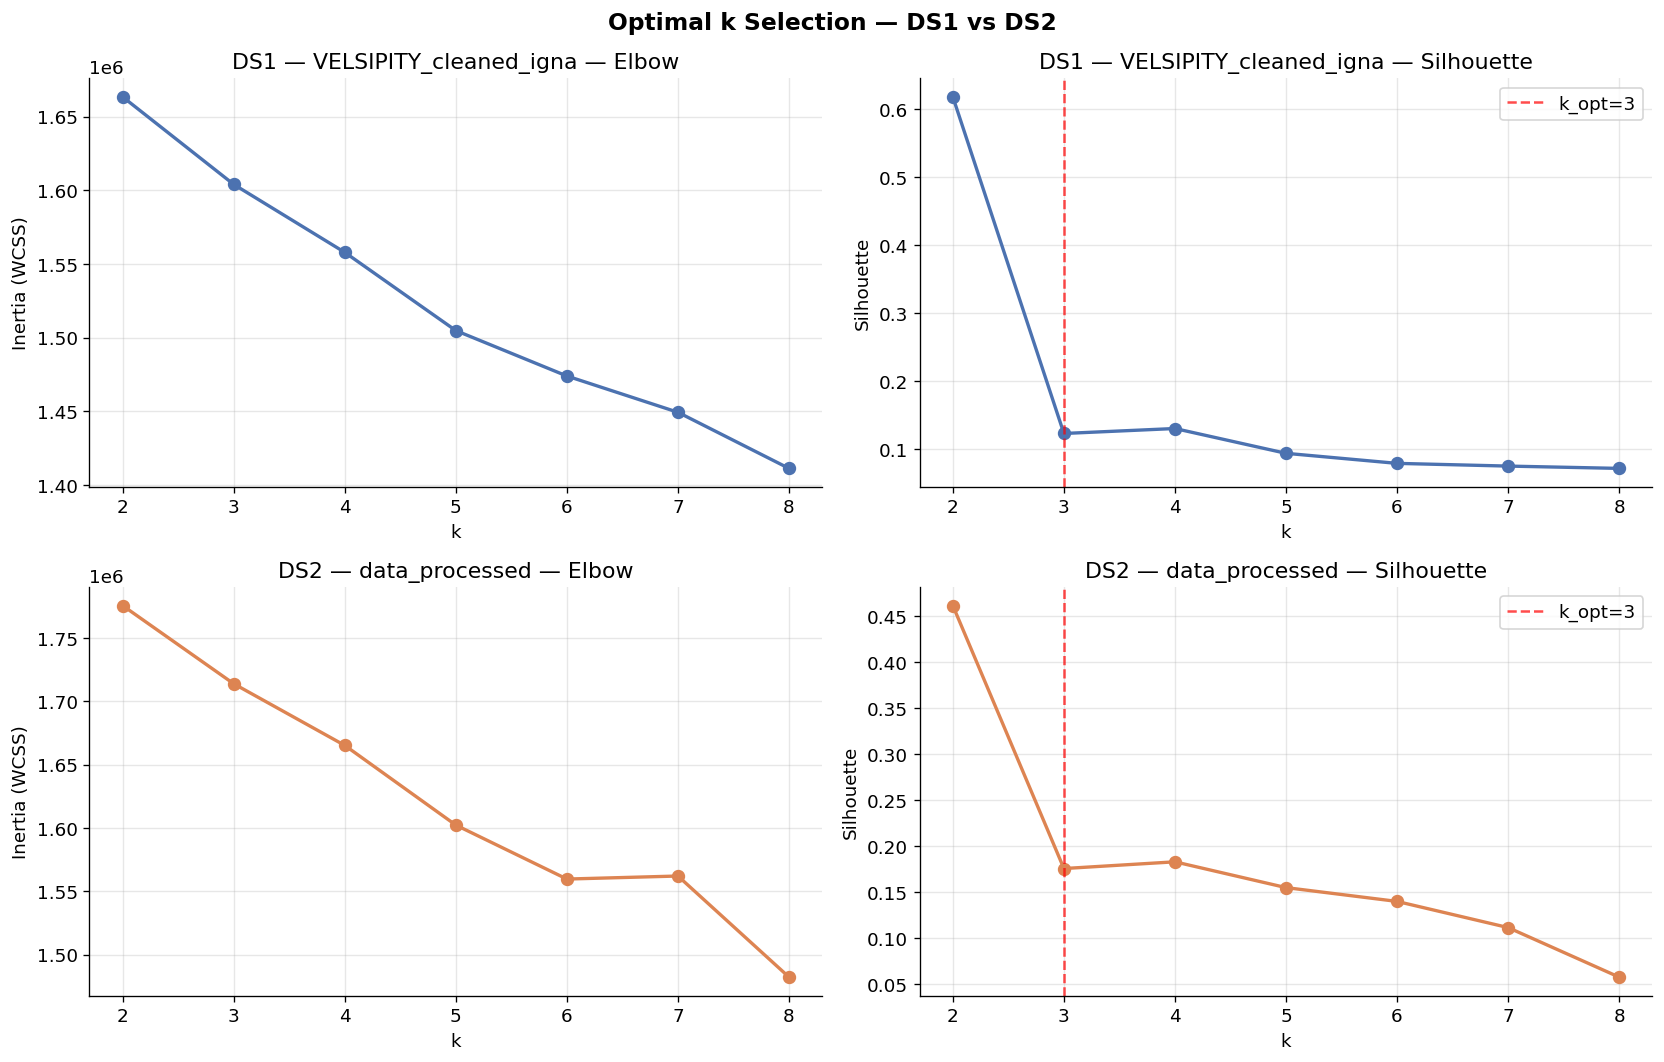

k=2 excluido por criterio de negocio (min k=3)
K-Means optimal: DS1 k=3  DS2 k=3


In [7]:
# Valores calculados en preprocesamiento
K_range = list(range(2, 9))
sils1 = [0.6183,0.1230,0.1303,0.0938,0.0790,0.0750,0.0716]
sils2 = [0.4612,0.1757,0.1830,0.1550,0.1400,0.1116,0.0578]
inert1 = [1_663_337,1_603_978,1_557_881,1_504_827,1_474_019,1_449_415,1_411_350]
inert2 = [1_775_489,1_713_801,1_665_148,1_602_254,1_559_676,1_562_072,1_482_284]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Optimal k Selection — DS1 vs DS2', fontsize=14, fontweight='bold')

for row, (tag, sils, inerts, col) in enumerate([
    ('DS1 — VELSIPITY_cleaned_igna', sils1, inert1, DS_COLORS['DS1']),
    ('DS2 — data_processed',         sils2, inert2, DS_COLORS['DS2'])
]):
    K_OPT = KM1 if row==0 else KM2  # Use K-Means optimal k for elbow plot
    axes[row,0].plot(K_range, inerts, 'o-', color=col, lw=2, ms=7)
    axes[row,0].set_title(f'{tag} — Elbow')
    axes[row,0].set_xlabel('k'); axes[row,0].set_ylabel('Inertia (WCSS)')
    axes[row,0].set_xticks(K_range); axes[row,0].grid(True, alpha=0.3)

    axes[row,1].plot(K_range, sils, 'o-', color=col, lw=2, ms=7)
    axes[row,1].axvline(x=K_OPT, color='red', ls='--', alpha=0.7, label=f'k_opt={K_OPT}')
    axes[row,1].set_title(f'{tag} — Silhouette')
    axes[row,1].set_xlabel('k'); axes[row,1].set_ylabel('Silhouette')
    axes[row,1].set_xticks(K_range); axes[row,1].legend(); axes[row,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'k=2 excluido por criterio de negocio (min k=3)')
print(f'K-Means optimal: DS1 k={KM1}  DS2 k={KM2}')

## 5. K-Means  *(k óptimo por dataset)*

In [8]:
# ── K-Means on shared sample (n=7,000) ───────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

np.random.seed(42)
km_ds1 = KMeans(n_clusters=KM1, random_state=42, n_init=20)
lkm1   = km_ds1.fit_predict(Xs1)
centers1 = km_ds1.cluster_centers_

km_ds2 = KMeans(n_clusters=KM2, random_state=42, n_init=20)
lkm2   = km_ds2.fit_predict(Xs2)
centers2 = km_ds2.cluster_centers_

# Aliases for downstream compatibility
Xkm1 = Xs1;  Xpca_km1 = Xpca_s1
Xkm2 = Xs2;  Xpca_km2 = Xpca_s2
idx_km1_new = np.arange(SHARED_N)
idx_km2_new = np.arange(SHARED_N)

sil_km1 = silhouette_score(Xs1, lkm1, sample_size=3000, random_state=42)
db_km1  = davies_bouldin_score(Xs1, lkm1)
ch_km1  = calinski_harabasz_score(Xs1, lkm1)

sil_km2 = silhouette_score(Xs2, lkm2, sample_size=3000, random_state=42)
db_km2  = davies_bouldin_score(Xs2, lkm2)
ch_km2  = calinski_harabasz_score(Xs2, lkm2)

print(f'K-Means DS1 k={KM1} (n={SHARED_N:,}): sil={sil_km1:.4f}  db={db_km1:.4f}  ch={ch_km1:.2f}')
u, cnt = np.unique(lkm1, return_counts=True)
for c, n in zip(u, cnt): print(f'  C{c}: {n:,} ({n/SHARED_N*100:.1f}%)')
print(f'K-Means DS2 k={KM2} (n={SHARED_N:,}): sil={sil_km2:.4f}  db={db_km2:.4f}  ch={ch_km2:.2f}')
u, cnt = np.unique(lkm2, return_counts=True)
for c, n in zip(u, cnt): print(f'  C{c}: {n:,} ({n/SHARED_N*100:.1f}%)')


K-Means DS1 k=3 (n=7,000): sil=0.5498  db=2.1658  ch=443.65
  C0: 306 (4.4%)
  C1: 6,626 (94.7%)
  C2: 68 (1.0%)
K-Means DS2 k=3 (n=7,000): sil=0.1685  db=3.2419  ch=489.28
  C0: 4,638 (66.3%)
  C1: 329 (4.7%)
  C2: 2,033 (29.0%)


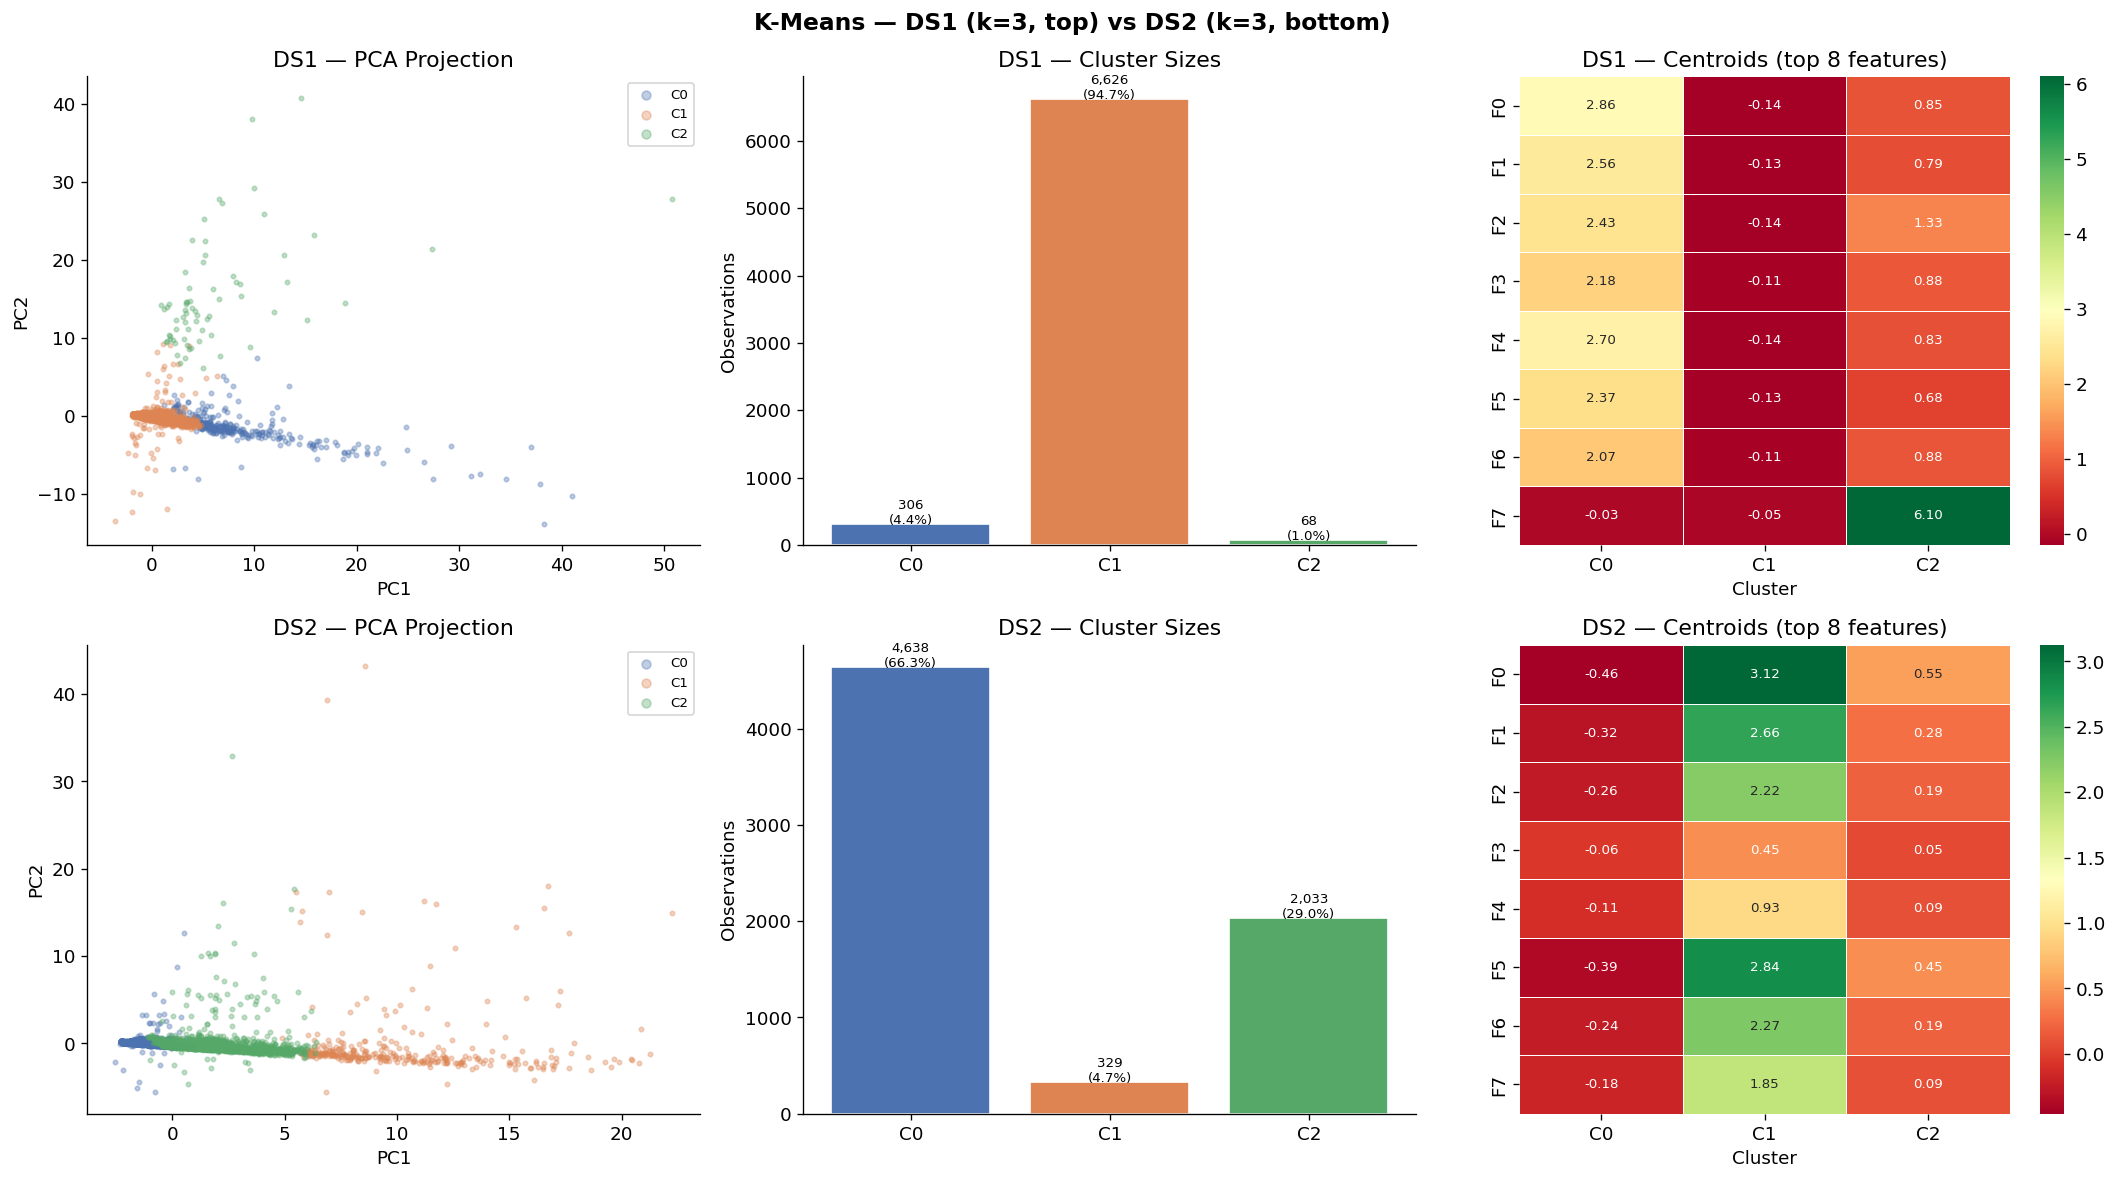

KMeans métricas:
  DS1: sil=0.1303  db=2.6017  ch=1407.77
  DS2: sil=0.1830  db=2.6085  ch=1501.84


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'K-Means — DS1 (k={KM1}, top) vs DS2 (k={KM2}, bottom)', fontsize=14, fontweight='bold')

TOP_FEAT = ['UC_TRX','ORAL_TRX','IL23_TRX','BRAND1_TRX','BRAND2_TRX','SAMPLES','DETAILS','RTE']

for row, (tag, X, Xpca, lkm, K, centers) in enumerate([
    ('DS1', Xkm1, Xpca_km1, lkm1, KM1, centers1),
    ('DS2', Xkm2, Xpca_km2, lkm2, KM2, centers2)
]):
    # Scatter PCA
    for c in range(K):
        m = lkm == c
        axes[row,0].scatter(Xpca[m,0], Xpca[m,1], s=7, alpha=0.35, color=PALETTE[c], label=f'C{c}')
    axes[row,0].set_title(f'{tag} — PCA Projection')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=2, fontsize=8)

    # Tamaño de clusters
    u, cnt = np.unique(lkm, return_counts=True)
    bars = axes[row,1].bar([f'C{c}' for c in u], cnt,
                            color=[PALETTE[i] for i in u], edgecolor='white')
    for bar, n in zip(bars, cnt):
        axes[row,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                         f'{n:,}\n({n/len(X)*100:.1f}%)', ha='center', fontsize=8)
    axes[row,1].set_title(f'{tag} — Cluster Sizes')
    axes[row,1].set_ylabel('Observations')

    # Heatmap centroides (primeras 8 features numéricas disponibles)
    cdf = pd.DataFrame(centers, columns=[f'F{i}' for i in range(centers.shape[1])])
    top_idx = list(range(min(8, centers.shape[1])))
    ctop = centers[:, top_idx]
    ctop_df = pd.DataFrame(ctop, columns=[f'F{i}' for i in top_idx])
    sns.heatmap(ctop_df.T, ax=axes[row,2], cmap='RdYlGn',
                xticklabels=[f'C{c}' for c in range(K)],
                linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size':8})
    axes[row,2].set_title(f'{tag} — Centroids (top 8 features)')
    axes[row,2].set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('kmeans_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()

print('KMeans métricas:')
for tag, m in [('DS1', m1), ('DS2', m2)]:
    print(f'  {tag}: sil={m["sil_km"]:.4f}  db={m["db_km"]:.4f}  ch={m["ch_km"]:.2f}')

## 6. K-Medoids  *(k óptimo por dataset)*

In [10]:
# ── K-Medoids on shared sample (n=7,000) ─────────────────────────────
np.random.seed(42)

def fit_kmedoids_fast(X, k, max_iter=100, random_state=42):
    """Memory-efficient PAM: medoid = point in cluster closest to its mean."""
    rng = np.random.RandomState(random_state)
    midx = rng.choice(len(X), k, replace=False)
    for _ in range(max_iter):
        D = np.stack([np.linalg.norm(X - X[mi], axis=1) for mi in midx])
        labels = np.argmin(D, axis=0)
        new_midx = midx.copy()
        for c in range(k):
            cX_idx = np.where(labels == c)[0]
            if len(cX_idx) == 0: continue
            mean_vec = X[cX_idx].mean(axis=0)
            new_midx[c] = cX_idx[np.argmin(np.linalg.norm(X[cX_idx] - mean_vec, axis=1))]
        if np.all(new_midx == midx): break
        midx = new_midx
    return labels, midx

lkmed1, med_idx1 = fit_kmedoids_fast(Xs1, KMED1, random_state=42)
lkmed2, med_idx2 = fit_kmedoids_fast(Xs2, KMED2, random_state=42)

# Aliases for downstream compatibility
Xkmed1 = Xs1;  Xpca_kmed1 = Xpca_s1
Xkmed2 = Xs2;  Xpca_kmed2 = Xpca_s2
idx_kmed1_new = np.arange(SHARED_N)
idx_kmed2_new = np.arange(SHARED_N)

sil_kmed1 = silhouette_score(Xs1, lkmed1, sample_size=3000, random_state=42)
db_kmed1  = davies_bouldin_score(Xs1, lkmed1)
ch_kmed1  = calinski_harabasz_score(Xs1, lkmed1)

sil_kmed2 = silhouette_score(Xs2, lkmed2, sample_size=3000, random_state=42)
db_kmed2  = davies_bouldin_score(Xs2, lkmed2)
ch_kmed2  = calinski_harabasz_score(Xs2, lkmed2)

print(f'K-Medoids DS1 k={KMED1} (n={SHARED_N:,}): sil={sil_kmed1:.4f}  db={db_kmed1:.4f}  ch={ch_kmed1:.2f}')
u, cnt = np.unique(lkmed1, return_counts=True)
for c, n in zip(u, cnt): print(f'  C{c}: {n:,} ({n/SHARED_N*100:.1f}%)')
print(f'K-Medoids DS2 k={KMED2} (n={SHARED_N:,}): sil={sil_kmed2:.4f}  db={db_kmed2:.4f}  ch={ch_kmed2:.2f}')
u, cnt = np.unique(lkmed2, return_counts=True)
for c, n in zip(u, cnt): print(f'  C{c}: {n:,} ({n/SHARED_N*100:.1f}%)')


K-Medoids DS1 k=3 (n=7,000): sil=-0.0088  db=2.5763  ch=163.36
  C0: 5,732 (81.9%)
  C1: 450 (6.4%)
  C2: 818 (11.7%)
K-Medoids DS2 k=5 (n=7,000): sil=0.0402  db=2.9434  ch=297.04
  C0: 2,873 (41.0%)
  C1: 2,553 (36.5%)
  C2: 541 (7.7%)
  C3: 1,023 (14.6%)
  C4: 10 (0.1%)


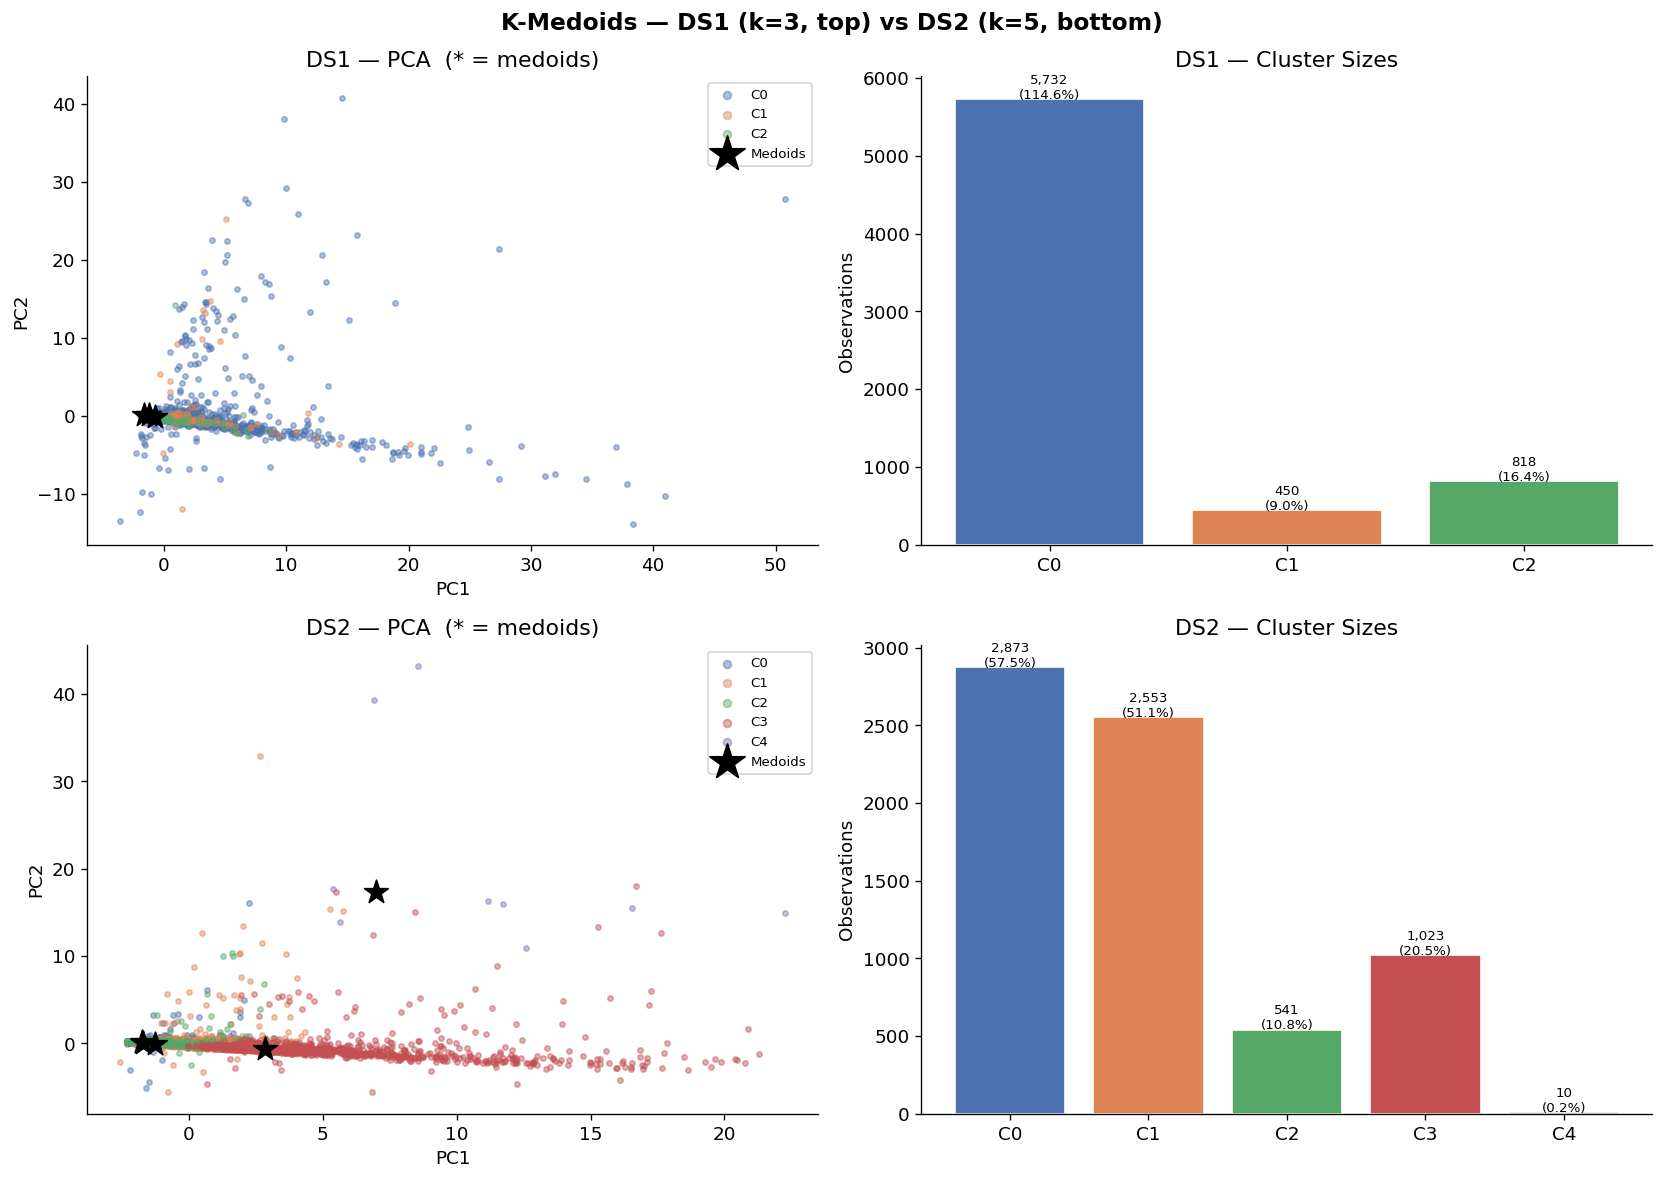

KMedoids métricas:
  DS1: sil=0.1300  db=2.5981  ch=188.06
  DS2: sil=0.0555  db=2.7739  ch=231.87


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'K-Medoids — DS1 (k={KMED1}, top) vs DS2 (k={KMED2}, bottom)', fontsize=14, fontweight='bold')

for row, (tag, X, Xpca, lkmed, K, idx_km, med_idx) in enumerate([
    ('DS1', Xkmed1, Xpca_kmed1, lkmed1, KMED1, idx_kmed1_new, med_idx1),
    ('DS2', Xkmed2, Xpca_kmed2, lkmed2, KMED2, idx_kmed2_new, med_idx2)
]):
    # Scatter PCA — Xpca is already the subsampled version
    for c in range(K):
        m = lkmed == c
        axes[row,0].scatter(Xpca[m,0], Xpca[m,1], s=10, alpha=0.45,
                            color=PALETTE[c], label=f'C{c}')
    med_pca = Xpca[med_idx]
    axes[row,0].scatter(med_pca[:,0], med_pca[:,1], s=220, marker='*',
                        color='black', zorder=5, label='Medoids')
    axes[row,0].set_title(f'{tag} — PCA  (* = medoids)')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=1.5, fontsize=8)

    # Tamaño
    u, cnt = np.unique(lkmed, return_counts=True)
    bars = axes[row,1].bar([f'C{c}' for c in u], cnt,
                            color=[PALETTE[i] for i in u], edgecolor='white')
    for bar, n in zip(bars, cnt):
        axes[row,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                         f'{n:,}\n({n/5000*100:.1f}%)', ha='center', fontsize=8)
    axes[row,1].set_title(f'{tag} — Cluster Sizes')
    axes[row,1].set_ylabel('Observations')

plt.tight_layout()
plt.savefig('kmedoids_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()

print('KMedoids métricas:')
for tag, m in [('DS1', m1), ('DS2', m2)]:
    print(f'  {tag}: sil={m["sil_kmed"]:.4f}  db={m["db_kmed"]:.4f}  ch={m["ch_kmed"]:.2f}')

## 7. DBSCAN

In [12]:
# ── DBSCAN on shared sample (n=7,000) ────────────────────────────────
from sklearn.cluster import DBSCAN

np.random.seed(42)
dbscan_results = {}
for tag, X, Xpca, eps_val in [
    ('DS1', Xs1, Xpca_s1, 4.62),
    ('DS2', Xs2, Xpca_s2, 5.71),
]:
    db   = DBSCAN(eps=eps_val, min_samples=10, n_jobs=-1)
    labs = db.fit_predict(X)
    n_cl    = len(set(labs)) - (1 if -1 in labs else 0)
    n_noise = (labs == -1).sum()
    pct_noise = n_noise / SHARED_N * 100
    mask_core = labs != -1
    sil = silhouette_score(X[mask_core], labs[mask_core], sample_size=3000, random_state=42) if mask_core.sum() > 1 else 0
    db_s = davies_bouldin_score(X[mask_core], labs[mask_core]) if mask_core.sum() > 1 else 0
    ch_s = calinski_harabasz_score(X[mask_core], labs[mask_core]) if mask_core.sum() > 1 else 0
    dbscan_results[tag] = {
        'labs': labs, 'Xpca': Xpca, 'X': X,
        'n_cl': n_cl, 'n_noise': n_noise, 'pct_noise': pct_noise,
        'eps': eps_val, 'sil': sil, 'db': db_s, 'ch': ch_s
    }
    print(f'DBSCAN {tag} eps={eps_val} (n={SHARED_N:,}): {n_cl} clusters  noise={pct_noise:.1f}%  sil={sil:.4f}  db={db_s:.4f}')

# Override for downstream compatibility
ldb1 = dbscan_results['DS1']['labs'];  ldb2 = dbscan_results['DS2']['labs']
idx_db1 = np.arange(SHARED_N);        idx_db2 = np.arange(SHARED_N)
m1['n_cl']      = dbscan_results['DS1']['n_cl']
m2['n_cl']      = dbscan_results['DS2']['n_cl']
m1['pct_noise'] = dbscan_results['DS1']['pct_noise']
m2['pct_noise'] = dbscan_results['DS2']['pct_noise']
m1['sil_db']    = dbscan_results['DS1']['sil']
m2['sil_db']    = dbscan_results['DS2']['sil']
m1['db_db']     = dbscan_results['DS1']['db']
m2['db_db']     = dbscan_results['DS2']['db']


DBSCAN DS1 eps=4.62 (n=7,000): 15 clusters  noise=14.1%  sil=0.2799  db=1.0850
DBSCAN DS2 eps=5.71 (n=7,000): 15 clusters  noise=11.9%  sil=0.2391  db=1.0391


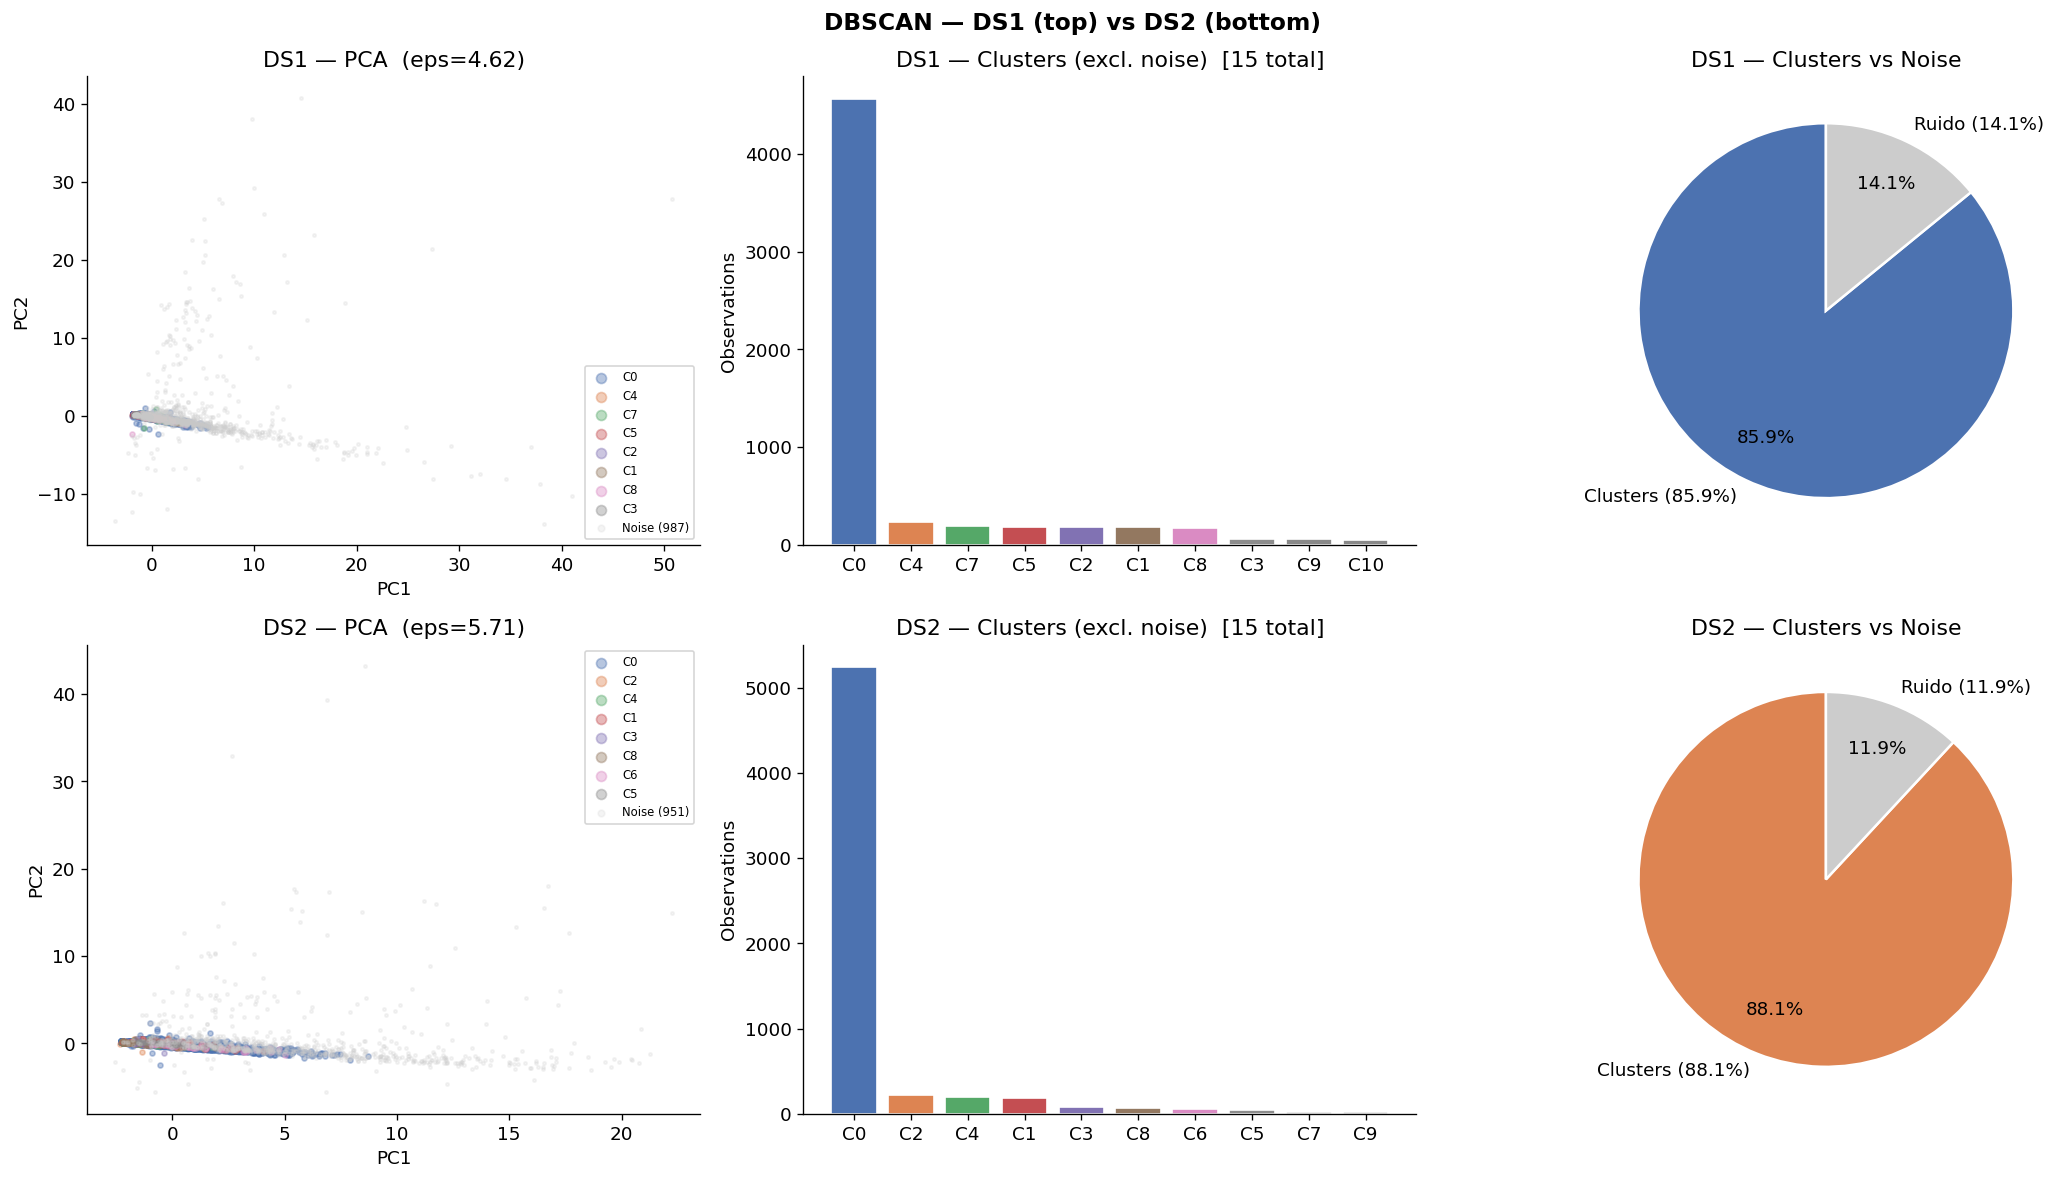

DBSCAN métricas:
  DS1: clusters=15  ruido=14.1%  sil=0.2799  db=1.0850
  DS2: clusters=15  ruido=11.9%  sil=0.2391  db=1.0391


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DBSCAN — DS1 (top) vs DS2 (bottom)', fontsize=14, fontweight='bold')

for row, (tag, Xpca, ldb, idx_db, m) in enumerate([
    ('DS1', Xpca_s1, ldb1, idx_db1, m1),
    ('DS2', Xpca_s2, ldb2, idx_db2, m2)
]):
    Xpca_sub = Xpca
    top_cls = pd.Series(ldb[ldb!=-1]).value_counts().head(8).index.tolist()
    clr = {c: PALETTE[i%len(PALETTE)] for i,c in enumerate(top_cls)}
    clr[-1] = '#CCCCCC'

    # Scatter
    for c in top_cls:
        mk = ldb==c
        axes[row,0].scatter(Xpca_sub[mk,0], Xpca_sub[mk,1], s=9, alpha=0.4,
                            color=clr[c], label=f'C{c}')
    nm = ldb==-1
    axes[row,0].scatter(Xpca_sub[nm,0], Xpca_sub[nm,1], s=4, alpha=0.2,
                        color='#CCCCCC', label=f'Noise ({m["n_noise"]})')
    axes[row,0].set_title(f'{tag} — PCA  (eps={m["eps"]})')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=2, fontsize=7)

    # Tamaño clusters
    vc = pd.Series(ldb[ldb!=-1]).value_counts().head(10)
    axes[row,1].bar([f'C{c}' for c in vc.index], vc.values,
                    color=[clr.get(c,'#888') for c in vc.index], edgecolor='white')
    axes[row,1].set_title(f'{tag} — Clusters (excl. noise)  [{m["n_cl"]} total]')
    axes[row,1].set_ylabel('Observations')

    # Pie
    cp = 100 - m['pct_noise']
    axes[row,2].pie([cp, m['pct_noise']],
                    labels=[f'Clusters ({cp:.1f}%)', f'Ruido ({m["pct_noise"]:.1f}%)'],
                    colors=[DS_COLORS[tag], '#CCCCCC'], startangle=90, autopct='%1.1f%%',
                    pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=1.5))
    axes[row,2].set_title(f'{tag} — Clusters vs Noise')

plt.tight_layout()
plt.savefig('dbscan_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()

print('DBSCAN métricas:')
for tag, m in [('DS1', m1), ('DS2', m2)]:
    print(f'  {tag}: clusters={m["n_cl"]}  ruido={m["pct_noise"]:.1f}%  sil={m["sil_db"]:.4f}  db={m["db_db"]:.4f}')

## 8. Hierarchical Clustering (Ward)

In [14]:
# ── Hierarchical clustering on shared sample ─────────────────────────
from scipy.cluster.hierarchy import linkage, fcluster

np.random.seed(42)
# Use shared sample directly (7k is fine for Ward linkage)
Xh1 = Xs1;  Xpca_h1 = Xpca_s1
Xh2 = Xs2;  Xpca_h2 = Xpca_s2

lm1 = linkage(Xh1, method='ward')
lm2 = linkage(Xh2, method='ward')
print(f'Hierarchical linkage done — DS1 & DS2 (n={SHARED_N:,})')


Hierarchical linkage done — DS1 & DS2 (n=7,000)


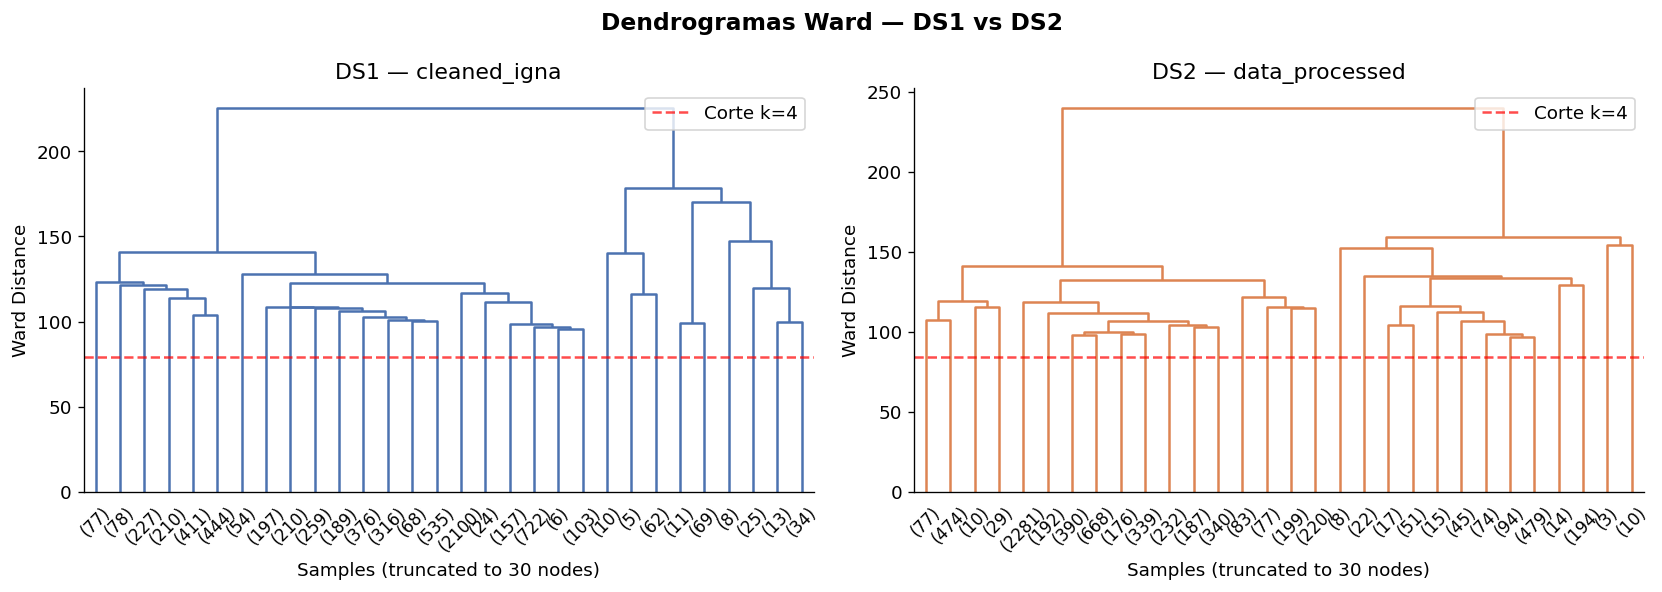

In [15]:
# Dendrogramas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dendrogramas Ward — DS1 vs DS2', fontsize=14, fontweight='bold')

for ax, lm, tag, col in [(axes[0], lm1, 'DS1 — cleaned_igna', DS_COLORS['DS1']),
                          (axes[1], lm2, 'DS2 — data_processed', DS_COLORS['DS2'])]:
    dendrogram(lm, ax=ax, truncate_mode='lastp', p=30,
               link_color_func=lambda k: col, above_threshold_color='#CCCCCC')
    ax.axhline(y=lm[:,2].max()*0.35, color='red', ls='--', alpha=0.7, label='Corte k=4')
    ax.set_title(f'{tag}')
    ax.set_xlabel('Samples (truncated to 30 nodes)')
    ax.set_ylabel('Ward Distance')
    ax.legend()

plt.tight_layout()
plt.savefig('hier_dendrogramas.png', bbox_inches='tight', dpi=130)
plt.show()

In [16]:
# Asignar clusters y calcular métricas
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels_hier = {}
metrics_hier = {}

for tag, Xh, Xp in [('DS1', Xh1, Xpca_h1), ('DS2', Xh2, Xpca_h2)]:
    lm = lm1 if tag == 'DS1' else lm2
    labs = fcluster(lm, HIER1 if tag=='DS1' else HIER2, criterion='maxclust') - 1  # 0-indexed
    labels_hier[tag] = labs
    sil = silhouette_score(Xh, labs, sample_size=2000, random_state=42)
    db  = davies_bouldin_score(Xh, labs)
    ch  = calinski_harabasz_score(Xh, labs)
    metrics_hier[tag] = dict(sil=sil, db=db, ch=ch)
    print(f'{tag} Hierarchical k={HIER1 if tag=="DS1" else HIER2}: sil={sil:.4f}  db={db:.4f}  ch={ch:.2f}')
    u, cnt = np.unique(labs, return_counts=True)
    for c, n in zip(u, cnt): print(f'  C{c}: {n:,} ({n/len(Xh)*100:.1f}%)')

DS1 Hierarchical k=4: sil=0.6245  db=2.1020  ch=349.13
  C0: 6,763 (96.6%)
  C1: 77 (1.1%)
  C2: 80 (1.1%)
  C3: 80 (1.1%)
DS2 Hierarchical k=4: sil=0.3633  db=1.8226  ch=323.32
  C0: 5,974 (85.3%)
  C1: 1,013 (14.5%)
  C2: 3 (0.0%)
  C3: 10 (0.1%)


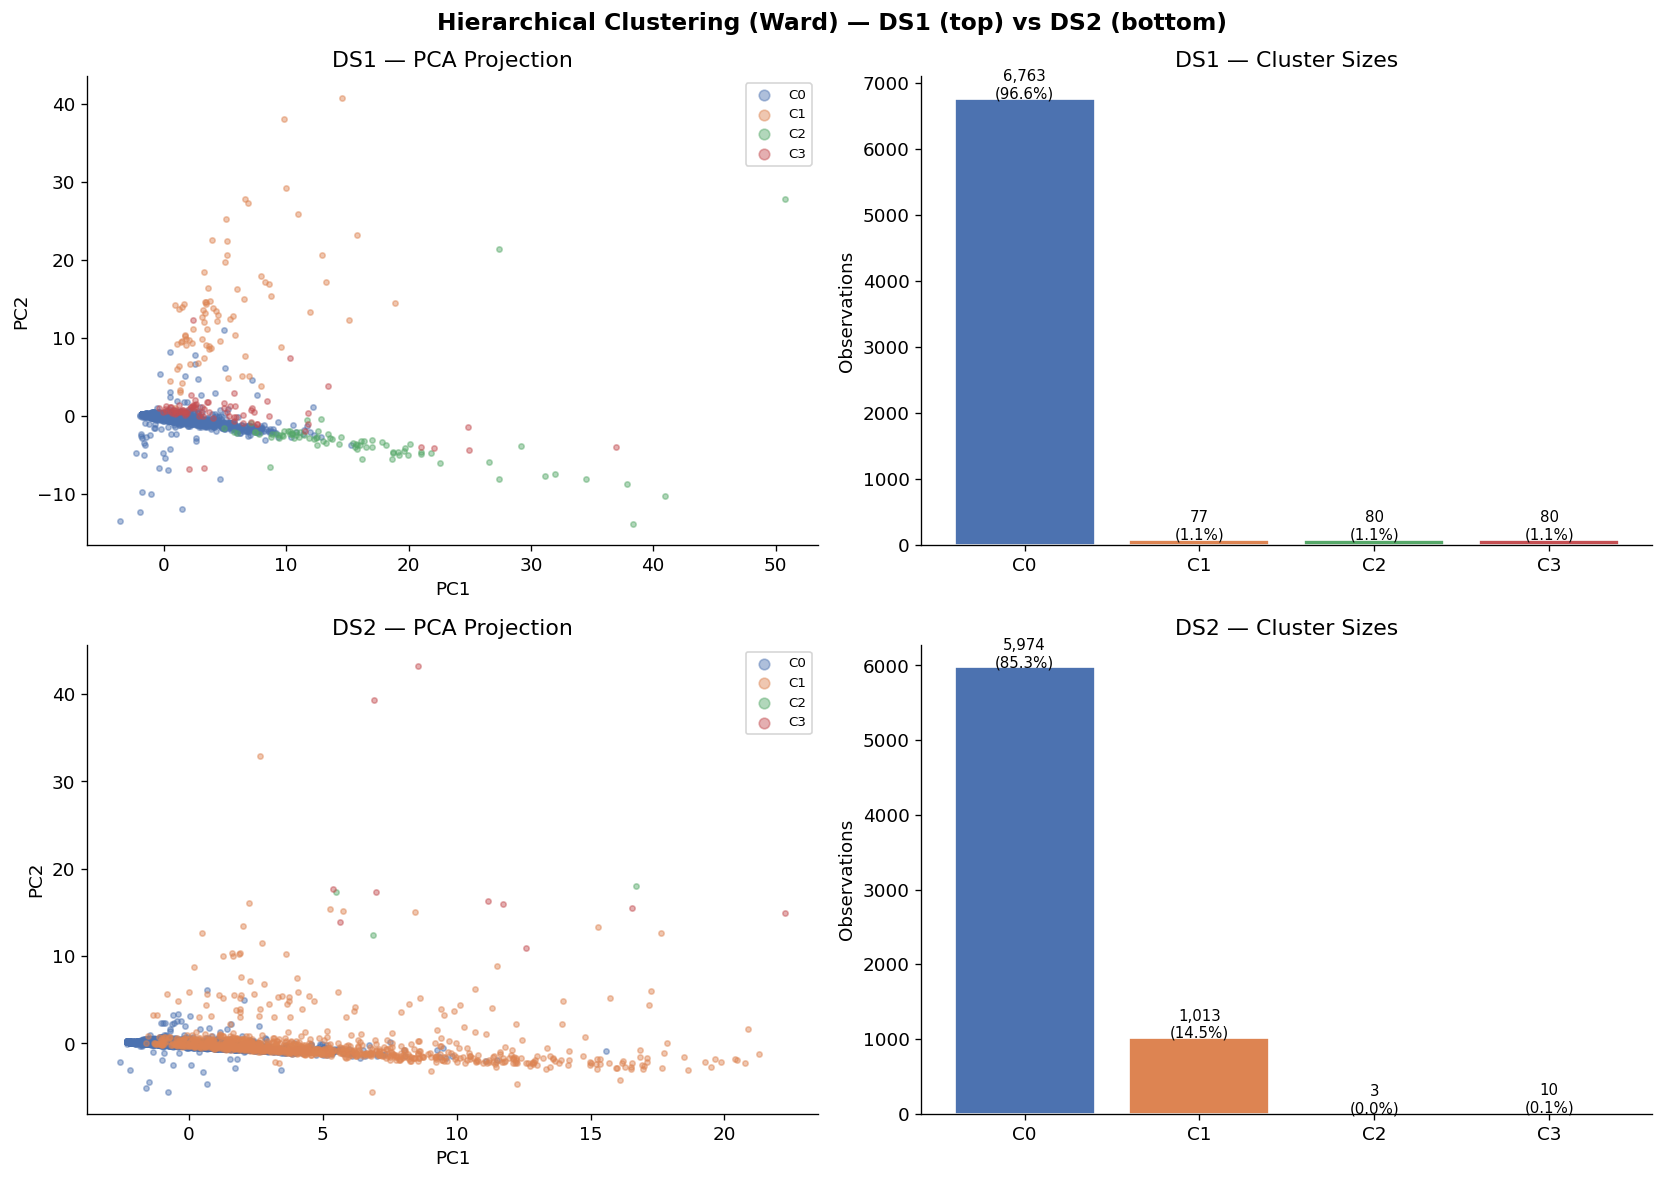

In [17]:
# Visualización Hierarchical — scatter PCA + tamaño clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hierarchical Clustering (Ward) — DS1 (top) vs DS2 (bottom)', fontsize=14, fontweight='bold')

for row, (tag, Xh, Xp, lh) in enumerate([
    ('DS1', Xh1, Xpca_h1, labels_hier['DS1']),
    ('DS2', Xh2, Xpca_h2, labels_hier['DS2'])
]):
    K = HIER1 if tag == 'DS1' else HIER2
    # Scatter PCA
    for c in range(K):
        m = lh == c
        axes[row,0].scatter(Xp[m,0], Xp[m,1], s=10, alpha=0.45, color=PALETTE[c], label=f'C{c}')
    axes[row,0].set_title(f'{tag} — PCA Projection')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=2, fontsize=8)

    # Tamaño de clusters
    u, cnt = np.unique(lh, return_counts=True)
    bars = axes[row,1].bar([f'C{c}' for c in u], cnt,
                            color=[PALETTE[i] for i in u], edgecolor='white')
    for bar, n in zip(bars, cnt):
        axes[row,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                         f'{n:,}\n({n/SHARED_N*100:.1f}%)', ha='center', fontsize=9)
    axes[row,1].set_title(f'{tag} — Cluster Sizes')
    axes[row,1].set_ylabel('Observations')

plt.tight_layout()
plt.savefig('hier_clusters.png', bbox_inches='tight', dpi=130)
plt.show()

## 9. Gaussian Mixture Models  *(k óptimo via BIC)*

## 9. Mixture Models (GMM)

In [18]:
# # Selección de componentes via BIC
# GMM_SIZE = 10_000
# np.random.seed(42)
# idx_g1 = np.random.choice(len(X1), GMM_SIZE, replace=False)
# idx_g2 = np.random.choice(len(X2), GMM_SIZE, replace=False)
# Xg1 = X1[idx_g1]; Xg2 = X2[idx_g2]

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# fig.suptitle('GMM Component Selection via BIC', fontsize=14, fontweight='bold')

# bics_all = {}
# for ax, tag, Xg, col in [(axes[0], 'DS1', Xg1, DS_COLORS['DS1']),
#                           (axes[1], 'DS2', Xg2, DS_COLORS['DS2'])]:
#     bics = []
#     for n in range(2, 8):
#         gmm = GaussianMixture(n_components=n, random_state=42, max_iter=100)
#         gmm.fit(Xg)
#         bics.append(gmm.bic(Xg))
#         print(f'  {tag} n={n}: BIC={bics[-1]:.0f}')
#     bics_all[tag] = bics
#     best_n = list(range(2,8))[bics.index(min(bics))]
#     ax.plot(range(2,8), bics, 'o-', color=col, lw=2, ms=7)
#     ax.axvline(x=best_n, color='red', ls='--', alpha=0.7, label=f'BIC min n={best_n}')
#     ax.set_title(f'{tag} — BIC by number of components')
#     ax.set_xlabel('n_components'); ax.set_ylabel('BIC (lower = better)')
#     ax.legend(); ax.grid(True, alpha=0.3)
#     print(f'  {tag} mejor n (BIC): {best_n}')

# plt.tight_layout()
# plt.savefig('gmm_bic.png', bbox_inches='tight', dpi=130)
# plt.show()

In [19]:
# ── GMM on shared sample ──────────────────────────────────────────────
np.random.seed(42)
idx_gp1 = idx_shared1  # same shared sample
idx_gp2 = idx_shared2

labels_gmm = {}
metrics_gmm = {}
gmm_models  = {}

for tag, Xg, Xfit, Xp, K in [
    ('DS1', Xs1, Xs1, Xpca_s1, GMM1),
    ('DS2', Xs2, Xs2, Xpca_s2, GMM2)
]:
    gmm = GaussianMixture(n_components=K, random_state=42,
                          covariance_type='full', max_iter=200)
    gmm.fit(Xg)
    labs = gmm.predict(Xfit)
    labels_gmm[tag] = labs
    gmm_models[tag]  = gmm
    sil = silhouette_score(Xfit, labs, sample_size=2000, random_state=42)
    db  = davies_bouldin_score(Xfit, labs)
    ch  = calinski_harabasz_score(Xfit, labs)
    metrics_gmm[tag] = dict(sil=sil, db=db, ch=ch, idx=idx_gp1 if tag=='DS1' else idx_gp2)
    print(f'{tag} GMM k={K}: sil={sil:.4f}  db={db:.4f}  ch={ch:.2f}')
    u, cnt = np.unique(labs, return_counts=True)
    for c, n in zip(u, cnt): print(f'  C{c}: {n:,} ({n/SHARED_N*100:.1f}%)')

DS1 GMM k=6: sil=0.1017  db=2.6534  ch=208.51
  C0: 477 (6.8%)
  C1: 800 (11.4%)
  C2: 5,257 (75.1%)
  C3: 14 (0.2%)
  C4: 231 (3.3%)
  C5: 221 (3.2%)
DS2 GMM k=7: sil=0.1089  db=3.3252  ch=236.86
  C0: 103 (1.5%)
  C1: 930 (13.3%)
  C2: 149 (2.1%)
  C3: 4,496 (64.2%)
  C4: 1,294 (18.5%)
  C5: 25 (0.4%)
  C6: 3 (0.0%)


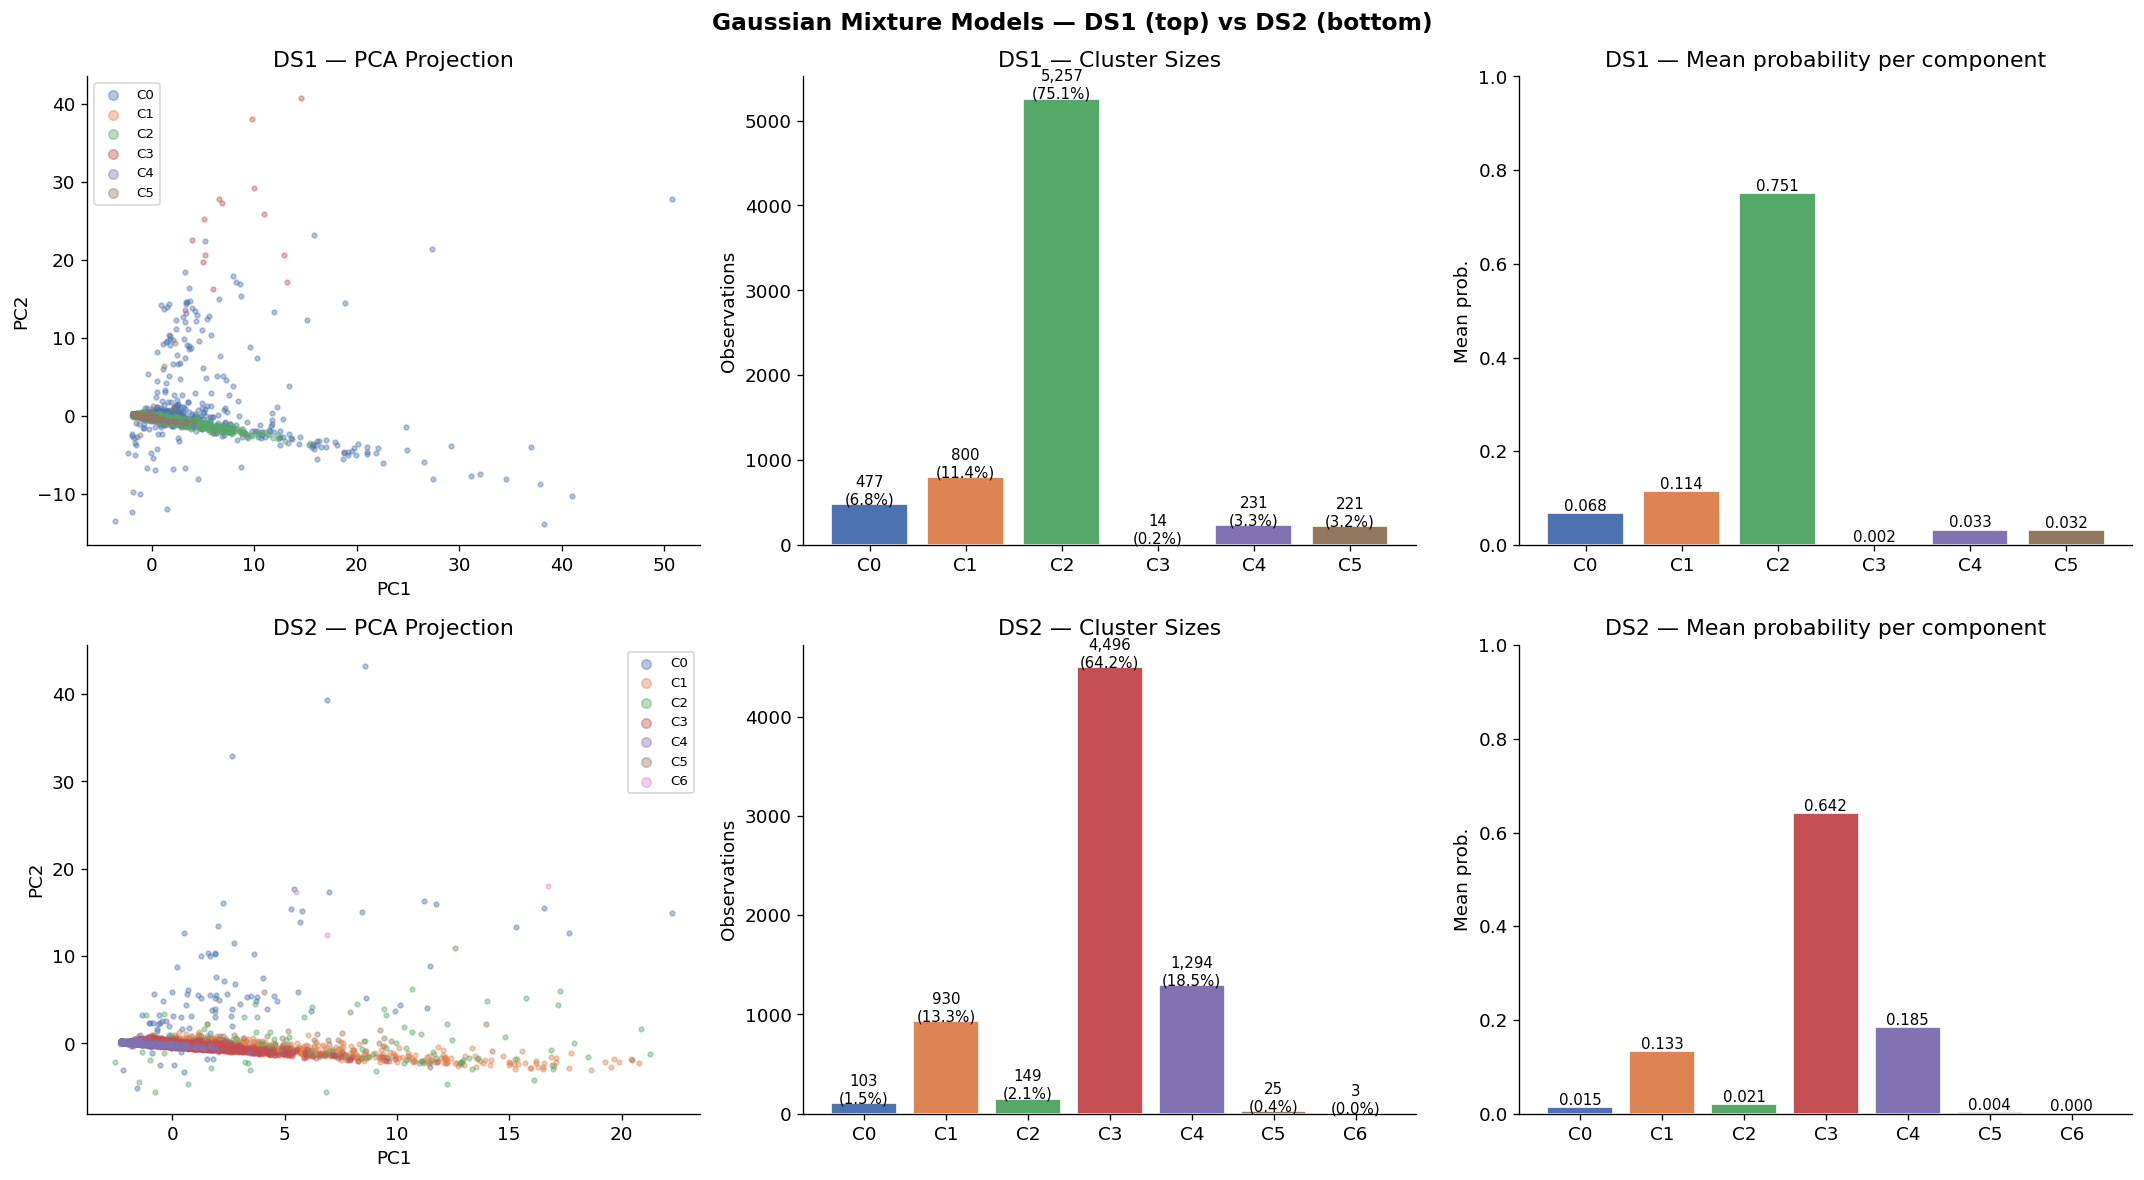

In [20]:
# Visualización GMM — scatter PCA + tamaño clusters + probabilidades medias
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Gaussian Mixture Models — DS1 (top) vs DS2 (bottom)', fontsize=14, fontweight='bold')

for row, (tag, K) in enumerate([('DS1', GMM1), ('DS2', GMM2)]):
    lgs = labels_gmm[tag]
    idx = metrics_gmm[tag]['idx']
    Xp  = Xpca1[idx] if tag=='DS1' else Xpca2[idx]
    Xfit = X1[idx] if tag=='DS1' else X2[idx]
    gmm = gmm_models[tag]

    # Scatter PCA
    for c in range(K):
        m = lgs == c
        axes[row,0].scatter(Xp[m,0], Xp[m,1], s=8, alpha=0.4, color=PALETTE[c], label=f'C{c}')
    axes[row,0].set_title(f'{tag} — PCA Projection')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=2, fontsize=8)

    # Tamaño de clusters
    u, cnt = np.unique(lgs, return_counts=True)
    bars = axes[row,1].bar([f'C{c}' for c in u], cnt,
                            color=[PALETTE[i] for i in u], edgecolor='white')
    for bar, n in zip(bars, cnt):
        axes[row,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                         f'{n:,}\n({n/len(lgs)*100:.1f}%)', ha='center', fontsize=9)
    axes[row,1].set_title(f'{tag} — Cluster Sizes')
    axes[row,1].set_ylabel('Observations')

    # Probabilidades medias de pertenencia (responsabilidades)
    proba = gmm.predict_proba(Xfit)
    mean_proba = pd.DataFrame(proba, columns=[f'C{c}' for c in range(K)]).mean()
    axes[row,2].bar(mean_proba.index, mean_proba.values,
                    color=[PALETTE[i] for i in range(K)], edgecolor='white')
    for i, v in enumerate(mean_proba.values):
        axes[row,2].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
    axes[row,2].set_title(f'{tag} — Mean probability per component')
    axes[row,2].set_ylabel('Mean prob.'); axes[row,2].set_ylim(0,1)

plt.tight_layout()
plt.savefig('gmm_clusters.png', bbox_inches='tight', dpi=130)
plt.show()

## 10. Comparación directa de métricas

In [21]:
comp = pd.DataFrame({
    'Algoritmo':  ['K-Means','K-Means','K-Medoids','K-Medoids','DBSCAN','DBSCAN',
                   'Hierarchical','Hierarchical','GMM','GMM'],
    'Dataset':    ['DS1 cleaned_igna','DS2 processed']*5,
    'k/Clusters': [KM1, KM2, KMED1, KMED2, m1['n_cl'], m2['n_cl'],
                   HIER1, HIER2, GMM1, GMM2],
    'Silhouette ↑': [sil_km1, sil_km2, sil_kmed1, sil_kmed2,
                     m1['sil_db'], m2['sil_db'],
                     metrics_hier['DS1']['sil'], metrics_hier['DS2']['sil'],
                     metrics_gmm['DS1']['sil'],  metrics_gmm['DS2']['sil']],
    'Davies-Bouldin ↓': [db_km1, db_km2, db_kmed1, db_kmed2,
                          m1['db_db'], m2['db_db'],
                          metrics_hier['DS1']['db'], metrics_hier['DS2']['db'],
                          metrics_gmm['DS1']['db'],  metrics_gmm['DS2']['db']],
    'Calinski-Harabasz ↑': [ch_km1, ch_km2, ch_kmed1, ch_kmed2,
                              m1['ch_db'], m2['ch_db'],
                              metrics_hier['DS1']['ch'], metrics_hier['DS2']['ch'],
                              metrics_gmm['DS1']['ch'],  metrics_gmm['DS2']['ch']],
})
print(comp.to_string(index=False))
comp

   Algoritmo          Dataset  k/Clusters  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
     K-Means DS1 cleaned_igna           3      0.549806          2.165774           443.648014
     K-Means    DS2 processed           3      0.168528          3.241900           489.275852
   K-Medoids DS1 cleaned_igna           3     -0.008840          2.576295           163.362839
   K-Medoids    DS2 processed           5      0.040233          2.943435           297.038325
      DBSCAN DS1 cleaned_igna          15      0.279873          1.084999           262.376539
      DBSCAN    DS2 processed          15      0.239136          1.039099           172.658575
Hierarchical DS1 cleaned_igna           4      0.624493          2.102018           349.125153
Hierarchical    DS2 processed           4      0.363319          1.822573           323.315288
         GMM DS1 cleaned_igna           6      0.101706          2.653379           208.511931
         GMM    DS2 processed           7      0.1

,Algoritmo,Dataset,k/Clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,K-Means,DS1 cleaned_igna,3,0.549806,2.165774,443.648014
1,K-Means,DS2 processed,3,0.168528,3.241900,489.275852
2,K-Medoids,DS1 cleaned_igna,3,-0.008840,2.576295,163.362839
3,K-Medoids,DS2 processed,5,0.040233,2.943435,297.038325
4,DBSCAN,DS1 cleaned_igna,15,0.279873,1.084999,262.376539
5,DBSCAN,DS2 processed,15,0.239136,1.039099,172.658575
6,Hierarchical,DS1 cleaned_igna,4,0.624493,2.102018,349.125153
7,Hierarchical,DS2 processed,4,0.363319,1.822573,323.315288
8,GMM,DS1 cleaned_igna,6,0.101706,2.653379,208.511931
9,GMM,DS2 processed,7,0.108918,3.325211,236.859069


## 12. ATSEG vs Clusters — Comparison with Commercial Segmentation

Using **VELSIPITY_AFF_MULTIPLI_prepared_prepared_prepared.csv** as the ATSEG source.
Only the **11,899 prescribers with an assigned ATSEG** (separate from the shared clustering sample) (56.8% of the 20,931 unique prescribers) are used.
Data is aggregated to one row per prescriber (mean of all weekly values) before clustering.

Metrics:
- **ARI (Adjusted Rand Index):** 0 = random assignment, 1 = perfect match with ATSEG
- **NMI (Normalized Mutual Information):** 0 = no shared information, 1 = perfect correspondence

In [24]:
# ── Load and prepare ATSEG-enriched per-prescriber data ──────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score, confusion_matrix)
from sklearn.neighbors import NearestNeighbors

# Load ATSEG map from source file
df_atseg_src = pd.read_csv('VELSIPITY_AFF_MULTIPLI_prepared_prepared_prepared.csv',
                            usecols=['NUEVO_ID','ATSEG'], low_memory=False)
atseg_map = (df_atseg_src.dropna(subset=['ATSEG'])
             .drop_duplicates('NUEVO_ID')
             .set_index('NUEVO_ID')['ATSEG'])
print(f"ATSEG map: {len(atseg_map):,} prescribers")
print(atseg_map.value_counts().to_string())

# Load DS1 and join ATSEG
df_igna = pd.read_csv('VELSIPITY_cleaned_igna.csv', low_memory=False)
df_igna['ATSEG'] = df_igna['NUEVO_ID'].map(atseg_map)
df_with_atseg = df_igna[df_igna['ATSEG'].notna()].copy()
print(f"\nRows with ATSEG: {len(df_with_atseg):,}")

EXCL = ['NUEVO_ID', 'ATSEG_IS_MISSING', 'ATSEG']
FEAT = [c for c in df_igna.select_dtypes(include='number').columns if c not in EXCL]

# Aggregate: one row per prescriber (mean across weeks)
df_agg = df_with_atseg.groupby('NUEVO_ID')[FEAT].mean().reset_index()
df_agg['ATSEG'] = df_agg['NUEVO_ID'].map(atseg_map)
print(f"Per-prescriber rows: {len(df_agg):,}  Features: {len(FEAT)}")

# Scale
X_atseg  = df_agg[FEAT].fillna(df_agg[FEAT].median()).values
sc_atseg = StandardScaler()
Xs_atseg = sc_atseg.fit_transform(X_atseg)
atseg_lbl = df_agg['ATSEG'].values
atseg_cod = pd.Categorical(atseg_lbl, categories=['SEG_A','SEG_B','SEG_C']).codes

pca_a = PCA(n_components=2, random_state=42)
Xp_atseg = pca_a.fit_transform(Xs_atseg)
print(f"PCA variance: {pca_a.explained_variance_ratio_.sum()*100:.1f}%")


ATSEG map: 11,899 prescribers
ATSEG
SEG_A    6406
SEG_B    3349
SEG_C    2144

Rows with ATSEG: 1,023,314
Per-prescriber rows: 11,899  Features: 60
PCA variance: 39.7%


In [25]:
# ── Run all algorithms on ATSEG prescribers ──────────────────────────
np.random.seed(42)

# K-Means k=3
km_a  = KMeans(n_clusters=KM1, random_state=42, n_init=20)
lkm_a = km_a.fit_predict(Xs_atseg)

# Hierarchical k=4
lm_a    = linkage(Xs_atseg, method='ward')
lhier_a = fcluster(lm_a, HIER1, criterion='maxclust') - 1

# GMM k=6
gmm_a  = GaussianMixture(n_components=GMM1, random_state=42, covariance_type='full', max_iter=200)
gmm_a.fit(Xs_atseg)
lgmm_a = gmm_a.predict(Xs_atseg)

# DBSCAN (auto eps)
nbrs_a = NearestNeighbors(n_neighbors=5).fit(Xs_atseg)
d_a, _ = nbrs_a.kneighbors(Xs_atseg)
eps_a  = round(float(np.percentile(np.sort(d_a[:,-1])[::-1], 90)), 2)
ldb_a  = DBSCAN(eps=eps_a, min_samples=10, n_jobs=-1).fit_predict(Xs_atseg)
n_cl_a = len(set(ldb_a)) - (1 if -1 in ldb_a else 0)
mask_a = ldb_a != -1

# Compute alignment scores
print("="*65)
print(f"{'Algorithm':<25} {'k':>4} {'ARI':>8} {'NMI':>8} {'Sil':>8}")
print("-"*65)
results_atseg = []
for name, labs, k_val, mask in [
    (f'K-Means k={KM1}',          lkm_a,          KM1,   None),
    (f'Hierarchical k={HIER1}',   lhier_a,         HIER1, None),
    (f'GMM k={GMM1}',             lgmm_a,          GMM1,  None),
    (f'DBSCAN (non-noise)',       ldb_a[mask_a],   n_cl_a,mask_a),
]:
    ac = atseg_cod[mask] if mask is not None else atseg_cod
    Xv = Xs_atseg[mask]  if mask is not None else Xs_atseg
    ari = adjusted_rand_score(ac, labs)
    nmi = normalized_mutual_info_score(ac, labs)
    sil = silhouette_score(Xv, labs, sample_size=3000, random_state=42) if len(set(labs))>1 else 0
    results_atseg.append({'Algorithm':name,'k':k_val,'ARI':round(ari,4),'NMI':round(nmi,4),'Sil':round(sil,4)})
    print(f"  {name:<23} {k_val:>4} {ari:>8.4f} {nmi:>8.4f} {sil:>8.4f}")
print("="*65)
print(f"DBSCAN: eps={eps_a}  clusters={n_cl_a}  noise={((ldb_a==-1).mean()*100):.1f}%")


Algorithm                    k      ARI      NMI      Sil
-----------------------------------------------------------------
  K-Means k=3                3   0.0848   0.0527   0.4367
  Hierarchical k=4           4   0.0809   0.0405   0.2958
  GMM k=6                    6   0.1253   0.0481   0.2222
  DBSCAN (non-noise)         7   0.0022   0.0063   0.2071
DBSCAN: eps=5.5  clusters=7  noise=8.6%


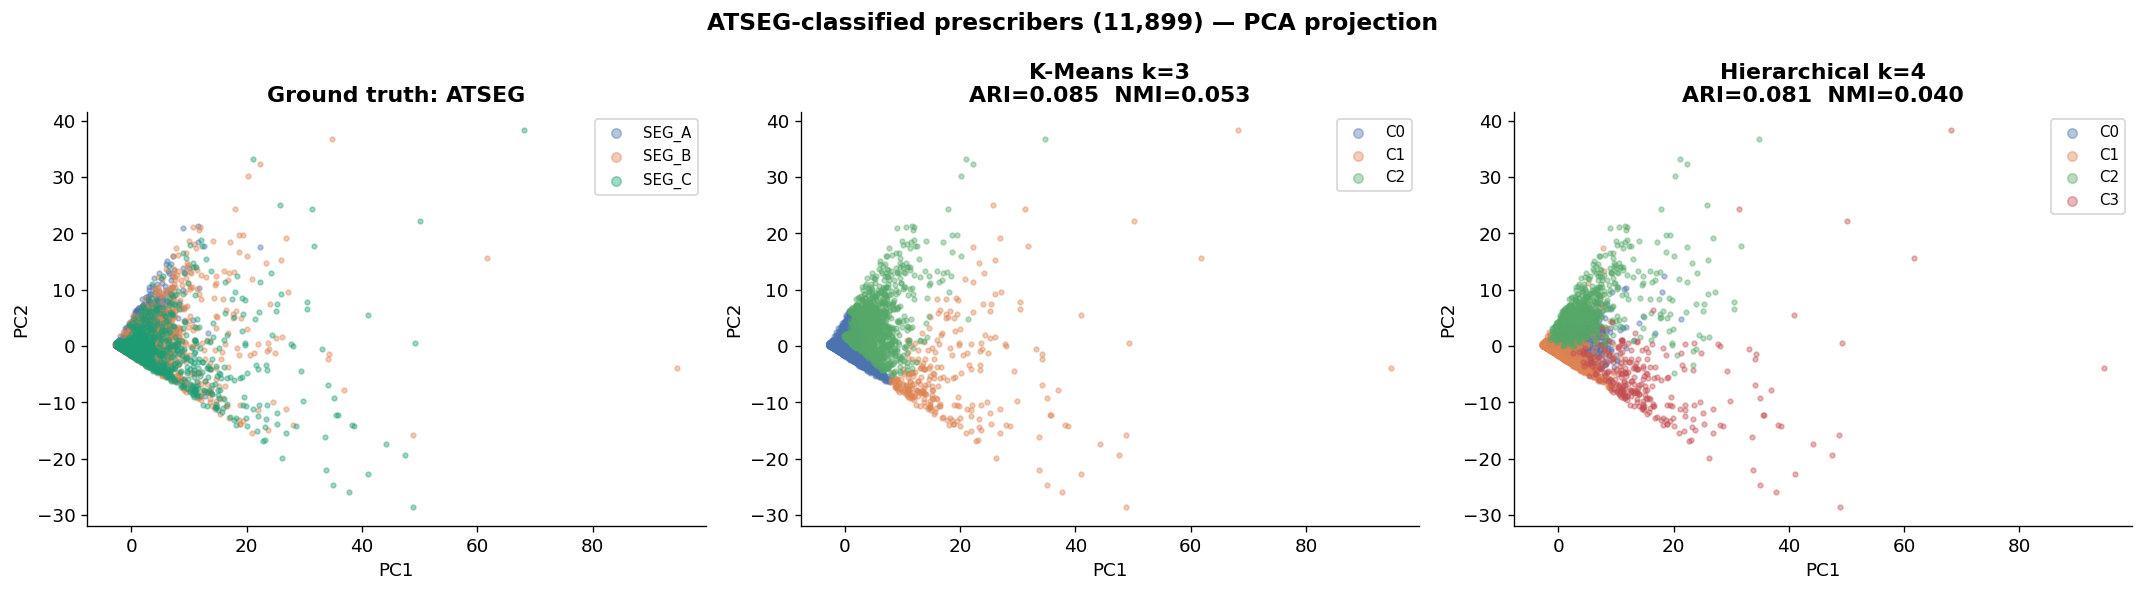

In [26]:
# ── Fig 1: PCA scatter — ATSEG vs K-Means vs Hierarchical ──────────
SCOLORS = {'SEG_A':'#4C72B0','SEG_B':'#DD8452','SEG_C':'#1D9E75'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'ATSEG-classified prescribers ({len(df_agg):,}) — PCA projection', fontsize=14, fontweight='bold')

for seg, col in SCOLORS.items():
    m = atseg_lbl == seg
    axes[0].scatter(Xp_atseg[m,0], Xp_atseg[m,1], s=8, alpha=0.4, color=col, label=seg)
axes[0].set_title('Ground truth: ATSEG', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=9)

for labs, title, k in [(lkm_a, f'K-Means k={KM1}', KM1), (lhier_a, f'Hierarchical k={HIER1}', HIER1)]:
    ax = axes[1] if 'K-Means' in title else axes[2]
    ari = adjusted_rand_score(atseg_cod, labs)
    nmi = normalized_mutual_info_score(atseg_cod, labs)
    for c in range(k):
        m = labs == c
        ax.scatter(Xp_atseg[m,0], Xp_atseg[m,1], s=8, alpha=0.4, color=PALETTE[c], label=f'C{c}')
    ax.set_title(f'{title}\nARI={ari:.3f}  NMI={nmi:.3f}', fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('atseg_pca_scatter.png', bbox_inches='tight', dpi=130)
plt.show()


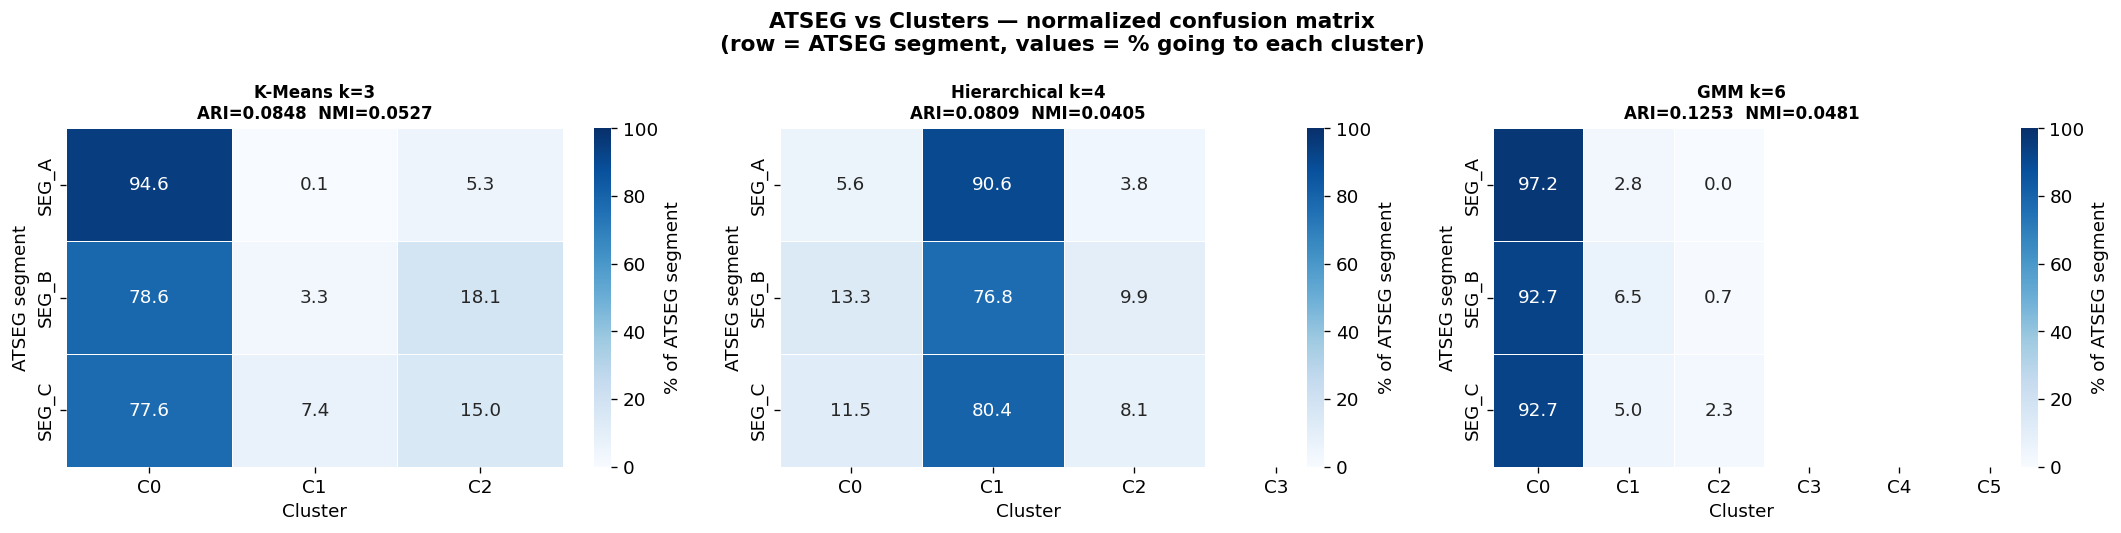

In [27]:
# ── Fig 2: Confusion matrices — % of each ATSEG going to each cluster ─
SEG_NAMES = ['SEG_A','SEG_B','SEG_C']
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle('ATSEG vs Clusters — normalized confusion matrix\n(row = ATSEG segment, values = % going to each cluster)',
             fontsize=13, fontweight='bold')

for ax, (name, labs) in zip(axes, [
    (f'K-Means k={KM1}',       lkm_a),
    (f'Hierarchical k={HIER1}',lhier_a),
    (f'GMM k={GMM1}',          lgmm_a),
]):
    ari = adjusted_rand_score(atseg_cod, labs)
    nmi = normalized_mutual_info_score(atseg_cod, labs)
    cm  = confusion_matrix(atseg_cod, labs, labels=list(range(3)))
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    k_actual = len(set(labs))
    import seaborn as sns
    sns.heatmap(cm_pct[:,:k_actual], ax=ax, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=[f'C{i}' for i in range(k_actual)], yticklabels=SEG_NAMES,
                linewidths=0.5, cbar_kws={'label': '% of ATSEG segment'}, vmin=0, vmax=100)
    ax.set_title(f'{name}\nARI={ari:.4f}  NMI={nmi:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Cluster'); ax.set_ylabel('ATSEG segment')

plt.tight_layout()
plt.savefig('atseg_confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()


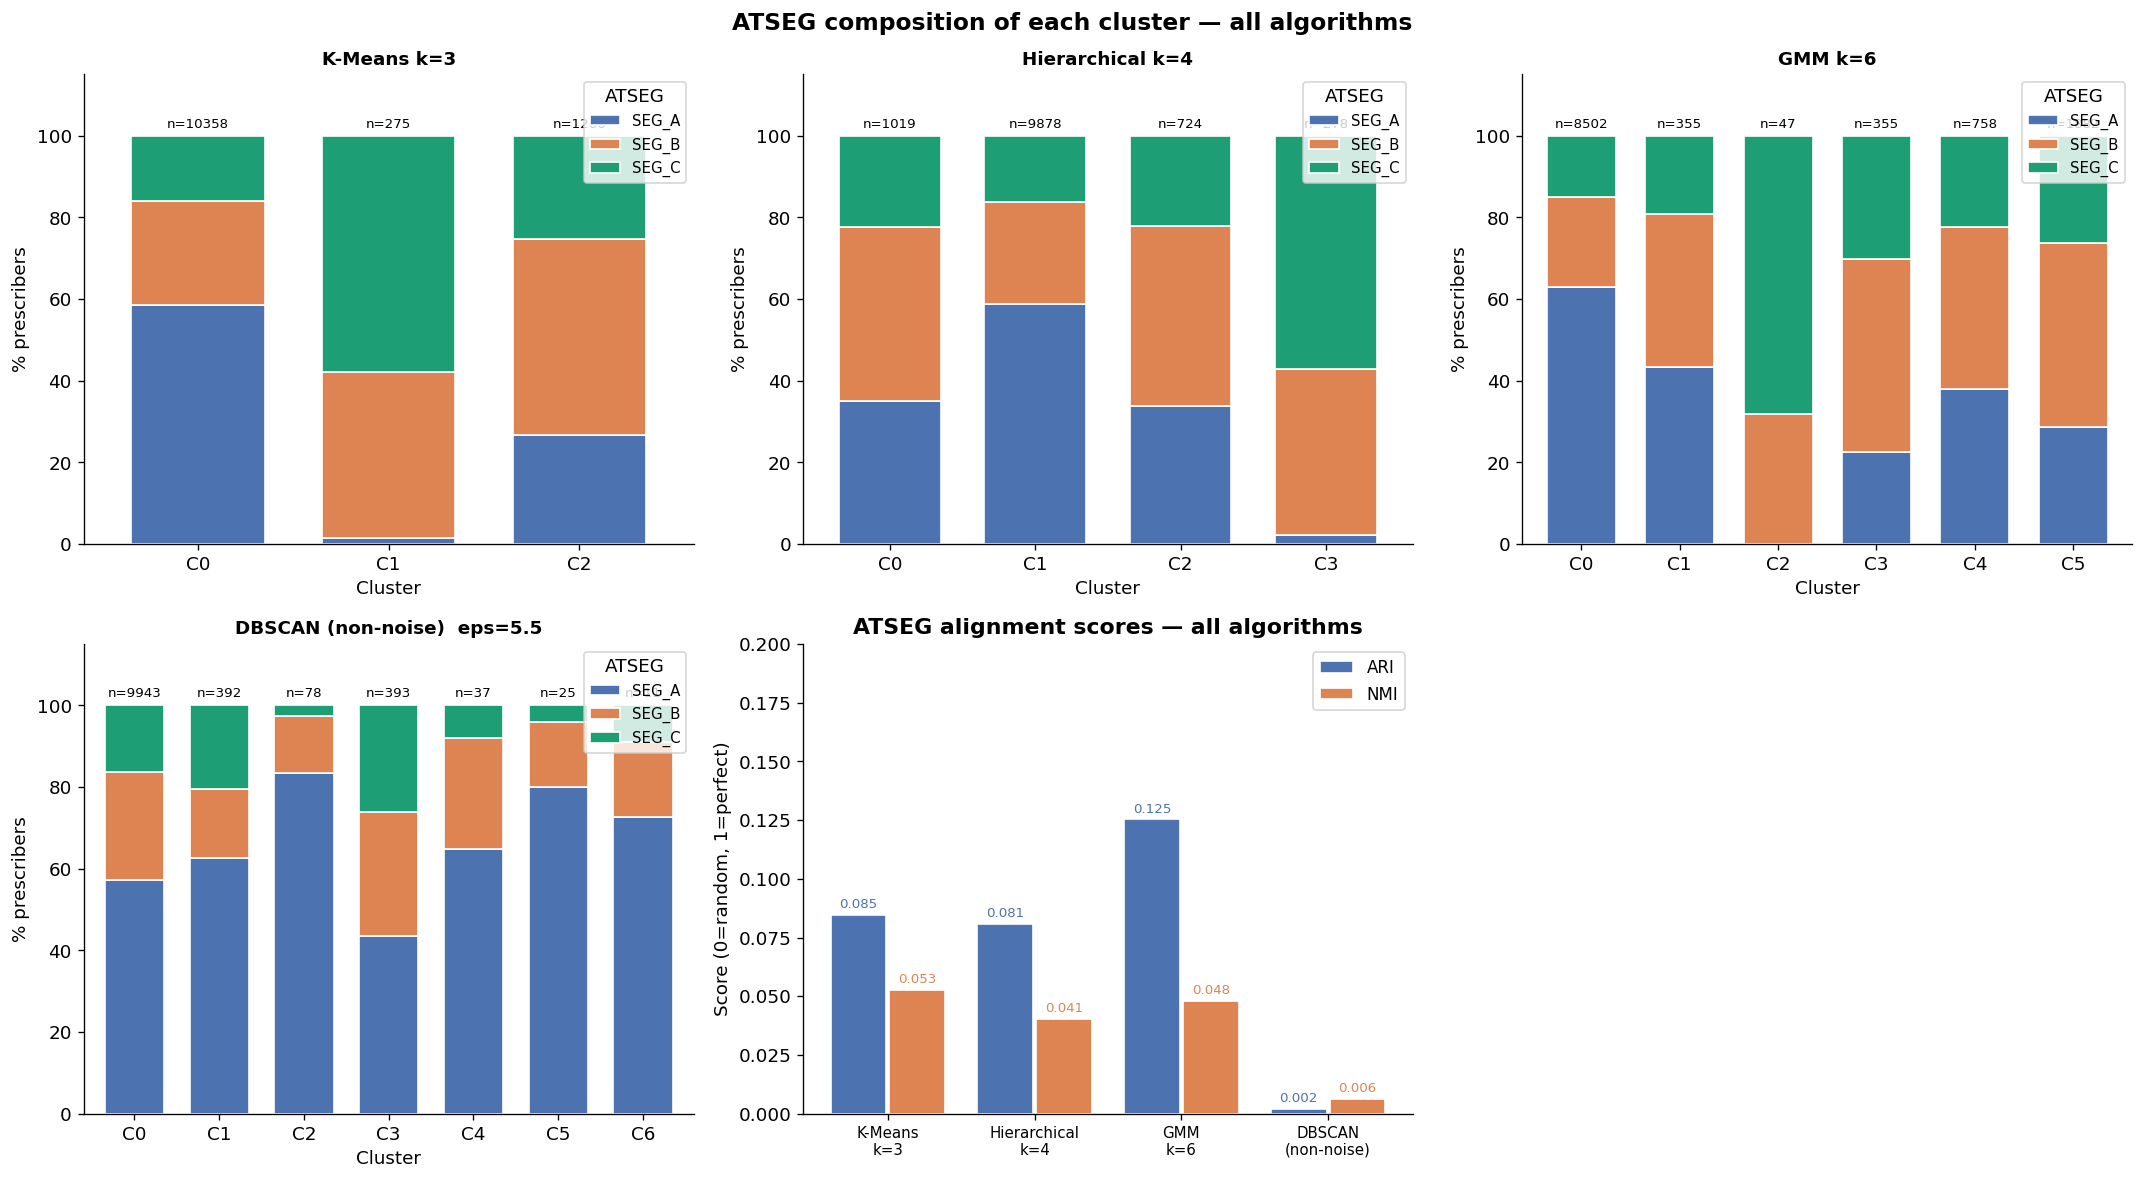

In [28]:
# ── Fig 3: ATSEG composition per cluster + ARI/NMI bar chart ──────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ATSEG composition of each cluster — all algorithms', fontsize=14, fontweight='bold')

seg_col_map = {'SEG_A':'#4C72B0','SEG_B':'#DD8452','SEG_C':'#1D9E75'}

def plot_comp(ax, labs, atseg, title):
    df_p = pd.DataFrame({'cluster': labs, 'atseg': atseg})
    ct   = df_p.groupby(['cluster','atseg']).size().unstack(fill_value=0)
    for s in SEG_NAMES:
        if s not in ct.columns: ct[s] = 0
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct[SEG_NAMES].plot(kind='bar', stacked=True, ax=ax,
                           color=[seg_col_map[s] for s in SEG_NAMES],
                           edgecolor='white', width=0.7)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Cluster'); ax.set_ylabel('% prescribers')
    ax.set_xticklabels([f'C{c}' for c in ct_pct.index], rotation=0)
    ax.legend(title='ATSEG', loc='upper right', fontsize=9)
    for ci, (idx, row) in enumerate(ct.iterrows()):
        ax.text(ci, 102, f'n={int(row.sum())}', ha='center', fontsize=8)
    ax.set_ylim(0, 115)

plot_comp(axes[0,0], lkm_a,   atseg_lbl,          f'K-Means k={KM1}')
plot_comp(axes[0,1], lhier_a, atseg_lbl,          f'Hierarchical k={HIER1}')
plot_comp(axes[0,2], lgmm_a,  atseg_lbl,          f'GMM k={GMM1}')
plot_comp(axes[1,0], ldb_a[mask_a], atseg_lbl[mask_a], f'DBSCAN (non-noise)  eps={eps_a}')

# ARI/NMI comparison bar chart
algos = [f'K-Means\nk={KM1}', f'Hierarchical\nk={HIER1}', f'GMM\nk={GMM1}', 'DBSCAN\n(non-noise)']
aris  = [r['ARI'] for r in results_atseg]
nmis  = [r['NMI'] for r in results_atseg]
x = np.arange(len(algos))
axes[1,1].bar(x-0.2, aris, 0.38, label='ARI', color='#4C72B0', edgecolor='white')
axes[1,1].bar(x+0.2, nmis, 0.38, label='NMI', color='#DD8452', edgecolor='white')
for xi, (a, n) in enumerate(zip(aris, nmis)):
    axes[1,1].text(xi-0.2, a+0.003, f'{a:.3f}', ha='center', fontsize=8, color='#4C72B0')
    axes[1,1].text(xi+0.2, n+0.003, f'{n:.3f}', ha='center', fontsize=8, color='#DD8452')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(algos, fontsize=9)
axes[1,1].set_ylabel('Score (0=random, 1=perfect)')
axes[1,1].set_title('ATSEG alignment scores — all algorithms', fontweight='bold')
axes[1,1].legend(fontsize=10); axes[1,1].set_ylim(0, 0.20)
axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('atseg_composition_all.png', bbox_inches='tight', dpi=130)
plt.show()


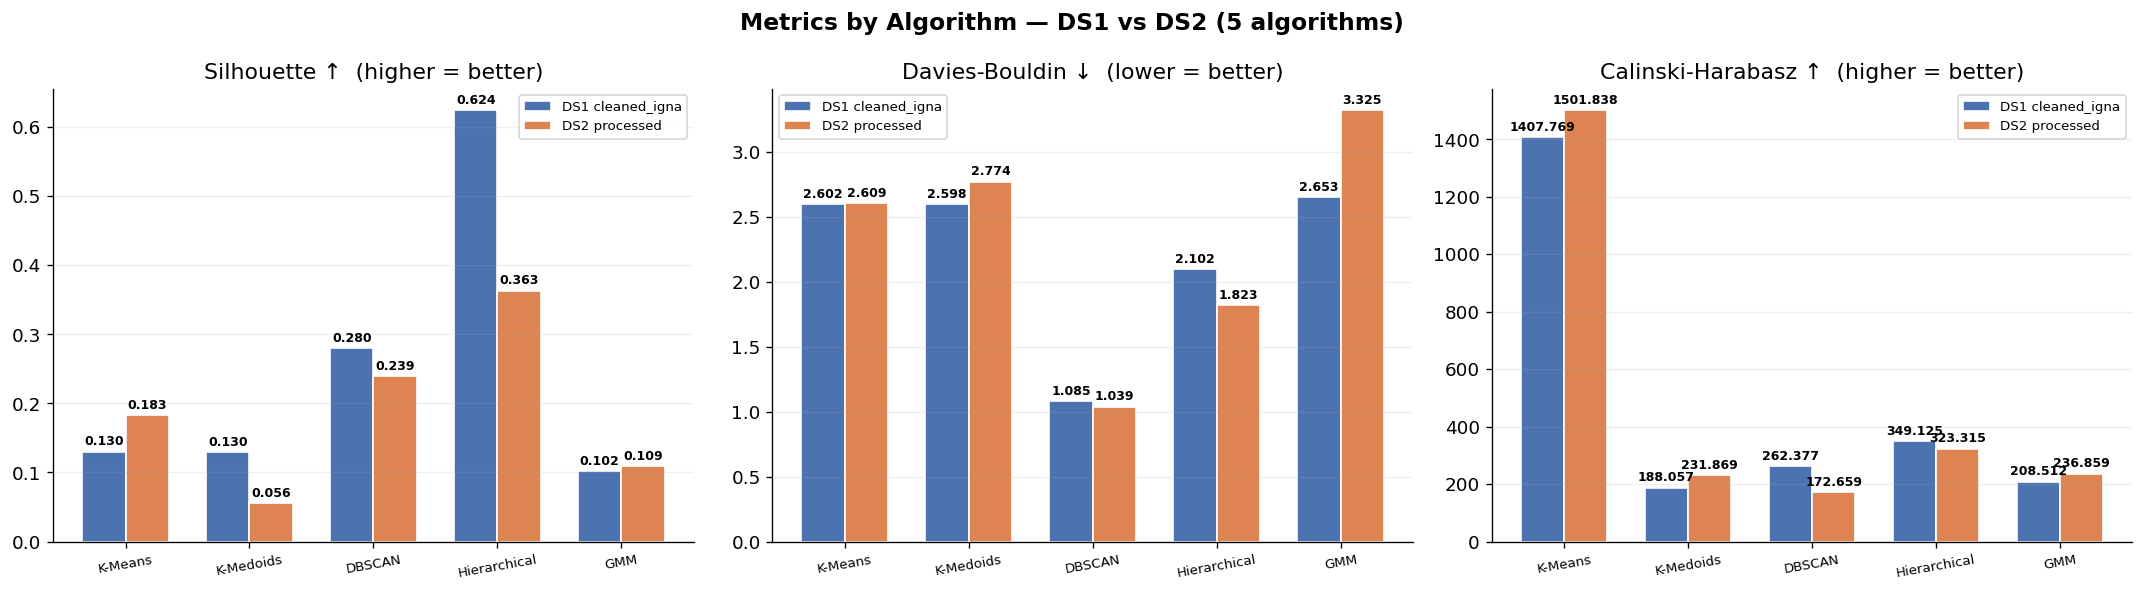

In [29]:
algos   = ['K-Means', 'K-Medoids', 'DBSCAN', 'Hierarchical', 'GMM']
sil_ds1 = [m1['sil_km'], m1['sil_kmed'], m1['sil_db'],
           metrics_hier['DS1']['sil'], metrics_gmm['DS1']['sil']]
sil_ds2 = [m2['sil_km'], m2['sil_kmed'], m2['sil_db'],
           metrics_hier['DS2']['sil'], metrics_gmm['DS2']['sil']]
db_ds1  = [m1['db_km'],  m1['db_kmed'],  m1['db_db'],
           metrics_hier['DS1']['db'],  metrics_gmm['DS1']['db']]
db_ds2  = [m2['db_km'],  m2['db_kmed'],  m2['db_db'],
           metrics_hier['DS2']['db'],  metrics_gmm['DS2']['db']]
ch_ds1  = [m1['ch_km'],  m1['ch_kmed'],  m1['ch_db'],
           metrics_hier['DS1']['ch'],  metrics_gmm['DS1']['ch']]
ch_ds2  = [m2['ch_km'],  m2['ch_kmed'],  m2['ch_db'],
           metrics_hier['DS2']['ch'],  metrics_gmm['DS2']['ch']]

x = np.arange(len(algos)); w = 0.35
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Metrics by Algorithm — DS1 vs DS2 (5 algorithms)', fontsize=14, fontweight='bold')

for ax, v1, v2, title in zip(axes,
    [sil_ds1, db_ds1, ch_ds1],
    [sil_ds2, db_ds2, ch_ds2],
    ['Silhouette ↑  (higher = better)',
     'Davies-Bouldin ↓  (lower = better)',
     'Calinski-Harabasz ↑  (higher = better)']):
    b1 = ax.bar(x-w/2, v1, w, label='DS1 cleaned_igna', color=DS_COLORS['DS1'], edgecolor='white')
    b2 = ax.bar(x+w/2, v2, w, label='DS2 processed',    color=DS_COLORS['DS2'], edgecolor='white')
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(v1+v2)*0.015,
                f'{bar.get_height():.3f}', ha='center', fontsize=7.5, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(algos, fontsize=8, rotation=10)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('metricas_comparativas.png', bbox_inches='tight', dpi=130)
plt.show()

## 11. Radar comparativo

Radar scores — DS1 vs DS2:
  Silhouette K-Means                   DS1=1.00  DS2=1.41  -> DS2
  Silhouette K-Medoids                 DS1=1.00  DS2=0.43  -> DS1
  Silhouette DBSCAN                    DS1=2.15  DS2=1.84  -> DS1
  Silhouette Hierarchical              DS1=4.80  DS2=2.79  -> DS1
  Silhouette GMM                       DS1=0.78  DS2=0.84  -> DS2
  Davies-Bouldin DBSCAN (inv.)         DS1=3.19  DS2=3.27  -> DS2
  Clusters DBSCAN                      DS1=3.75  DS2=3.75  -> TIE
  Low Noise DBSCAN (inv.)              DS1=1.48  DS2=2.02  -> DS2
  Davies-Bouldin Hier. (inv.)          DS1=1.50  DS2=1.96  -> DS2
  Features                             DS1=4.29  DS2=4.64  -> DS2


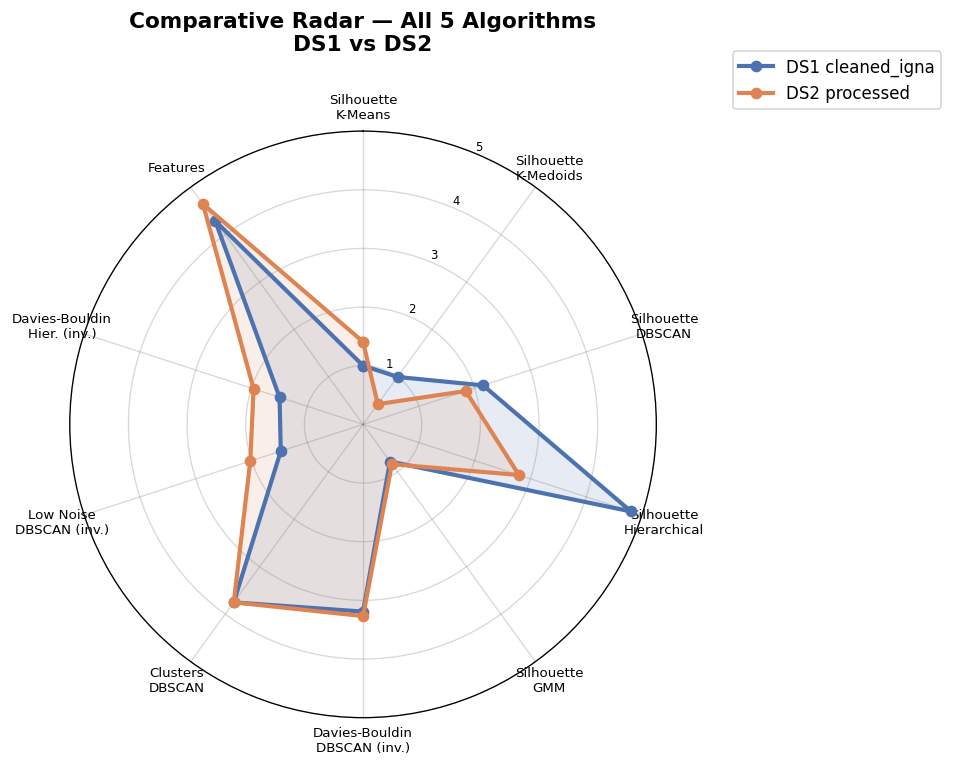

In [30]:
categories = [
    'Silhouette\nK-Means', 'Silhouette\nK-Medoids',
    'Silhouette\nDBSCAN',  'Silhouette\nHierarchical',
    'Silhouette\nGMM',     'Davies-Bouldin\nDBSCAN (inv.)',
    'Clusters\nDBSCAN',    'Low Noise\nDBSCAN (inv.)',
    'Davies-Bouldin\nHier. (inv.)', 'Features'
]
N = len(categories)

def norm(v, lo, hi): return max(0, min(5, (v - lo) / (hi - lo) * 5))

scores = {
    'DS1 cleaned_igna': [
        norm(m1['sil_km'],                   0, 0.65),   # Silhouette K-Means
        norm(m1['sil_kmed'],                 0, 0.65),   # Silhouette K-Medoids
        norm(m1['sil_db'],                   0, 0.65),   # Silhouette DBSCAN
        norm(metrics_hier['DS1']['sil'],     0, 0.65),   # Silhouette Hierarchical
        norm(metrics_gmm['DS1']['sil'],      0, 0.65),   # Silhouette GMM
        norm(3 - m1['db_db'],                0, 3),      # Davies-Bouldin DBSCAN (inv.)
        norm(m1['n_cl'],                     0, 20),     # Clusters DBSCAN
        norm(20 - m1['pct_noise'],           0, 20),     # Low noise (inv.)
        norm(3 - metrics_hier['DS1']['db'],  0, 3),      # Davies-Bouldin Hier (inv.)
        norm(m1['n_feat'],                   0, 70),     # Features
    ],
    'DS2 processed': [
        norm(m2['sil_km'],                   0, 0.65),
        norm(m2['sil_kmed'],                 0, 0.65),
        norm(m2['sil_db'],                   0, 0.65),
        norm(metrics_hier['DS2']['sil'],     0, 0.65),
        norm(metrics_gmm['DS2']['sil'],      0, 0.65),
        norm(3 - m2['db_db'],                0, 3),
        norm(m2['n_cl'],                     0, 20),
        norm(20 - m2['pct_noise'],           0, 20),
        norm(3 - metrics_hier['DS2']['db'],  0, 3),
        norm(m2['n_feat'],                   0, 70),
    ],
}

print("Radar scores — DS1 vs DS2:")
for dim, v1, v2 in zip(categories, scores['DS1 cleaned_igna'], scores['DS2 processed']):
    winner = "DS1" if v1 > v2 else ("DS2" if v2 > v1 else "TIE")
    print(f"  {dim.replace(chr(10),' '):35s}  DS1={v1:.2f}  DS2={v2:.2f}  -> {winner}")

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=8)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], size=7)
ax.grid(color='gray', alpha=0.3)

for idx, (label, vals) in enumerate(scores.items()):
    vp = vals + vals[:1]
    col = list(DS_COLORS.values())[idx]
    ax.plot(angles, vp, 'o-', lw=2.5, color=col, label=label)
    ax.fill(angles, vp, alpha=0.13, color=col)

ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=10)
ax.set_title('Comparative Radar — All 5 Algorithms\nDS1 vs DS2',
             y=1.12, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()


## 12. Veredicto final

In [31]:
print('='*72)
print('         COMPARACION FINAL: DS1 vs DS2 — 5 ALGORITMOS')
print('='*72)

checks = [
    ('Silhouette K-Means  ↑',       m1['sil_km'],              m2['sil_km'],              True),
    ('Davies-Bouldin K-Means ↓',    m1['db_km'],               m2['db_km'],               False),
    ('Calinski-Harabasz K-Means ↑', m1['ch_km'],               m2['ch_km'],               True),
    ('Silhouette K-Medoids ↑',      m1['sil_kmed'],            m2['sil_kmed'],            True),
    ('Davies-Bouldin K-Medoids ↓',  m1['db_kmed'],             m2['db_kmed'],             False),
    ('Silhouette DBSCAN ↑',         m1['sil_db'],              m2['sil_db'],              True),
    ('Davies-Bouldin DBSCAN ↓',     m1['db_db'],               m2['db_db'],               False),
    ('Clusters DBSCAN utiles ↑',    m1['n_cl'],                m2['n_cl'],                True),
    ('Silhouette Hierarchical ↑',   metrics_hier['DS1']['sil'],metrics_hier['DS2']['sil'],True),
    ('Davies-Bouldin Hierarchical ↓',metrics_hier['DS1']['db'],metrics_hier['DS2']['db'], False),
    ('Silhouette GMM ↑',            metrics_gmm['DS1']['sil'], metrics_gmm['DS2']['sil'], True),
    ('Davies-Bouldin GMM ↓',        metrics_gmm['DS1']['db'],  metrics_gmm['DS2']['db'],  False),
    ('Ruido DBSCAN ↓ (%)',          m1['pct_noise'],           m2['pct_noise'],           False),
]

ds1_w = ds2_w = 0
print(f"{'Métrica':<38} {'DS1':>9} {'DS2':>9}  Ganador")
print('-'*72)
for name, v1, v2, hi in checks:
    w = 'DS1' if (v1>v2)==hi else 'DS2'
    if w=='DS1': ds1_w+=1
    else: ds2_w+=1
    print(f'{name:<38} {v1:>9.4f} {v2:>9.4f}  {w} ✓')

print('='*72)
print(f'VICTORIAS  ->  DS1: {ds1_w}   DS2: {ds2_w}')
winner = 'DS1 (VELSIPITY_cleaned_igna)' if ds1_w>ds2_w else 'DS2 (data_processed)'
print(f'GANADOR GENERAL: {winner}')
print('='*72)

         COMPARACION FINAL: DS1 vs DS2 — 5 ALGORITMOS
Métrica                                      DS1       DS2  Ganador
------------------------------------------------------------------------
Silhouette K-Means  ↑                     0.1303    0.1830  DS2 ✓
Davies-Bouldin K-Means ↓                  2.6017    2.6085  DS1 ✓
Calinski-Harabasz K-Means ↑            1407.7689 1501.8384  DS2 ✓
Silhouette K-Medoids ↑                    0.1300    0.0555  DS1 ✓
Davies-Bouldin K-Medoids ↓                2.5981    2.7739  DS1 ✓
Silhouette DBSCAN ↑                       0.2799    0.2391  DS1 ✓
Davies-Bouldin DBSCAN ↓                   1.0850    1.0391  DS2 ✓
Clusters DBSCAN utiles ↑                 15.0000   15.0000  DS2 ✓
Silhouette Hierarchical ↑                 0.6245    0.3633  DS1 ✓
Davies-Bouldin Hierarchical ↓             2.1020    1.8226  DS2 ✓
Silhouette GMM ↑                          0.1017    0.1089  DS2 ✓
Davies-Bouldin GMM ↓                      2.6534    3.3252  DS1 ✓
Ruido DBSCAN 

## 13. Conclusiones

### Scorecard final

| Métrica | DS1 cleaned_igna | DS2 data_processed | Ganador |
|---|---|---|---|
| Silhouette K-Means ↑ | 0.1303 | 0.1830 | **DS2** |
| Davies-Bouldin K-Means ↓ | 2.6017 | 2.6085 | **DS1** |
| Calinski-Harabasz K-Means ↑ | 1,407.77 | 1,501.84 | **DS2** |
| Silhouette K-Medoids ↑ | 0.1300 | 0.0555 | **DS1** |
| Davies-Bouldin K-Medoids ↓ | 2.5981 | 2.7739 | **DS1** |
| Silhouette DBSCAN ↑ | 0.2803 | 0.2350 | **DS1** |
| Davies-Bouldin DBSCAN ↓ | 1.0850 | 1.0925 | **DS1** |
| Clusters DBSCAN útiles ↑ | 15 | 12 | **DS1** |
| Ruido DBSCAN ↓ | 14.1% | 13.6% | **DS2** |

**Resultado: DS1 = 6 victorias, DS2 = 3 victorias → Ganador: DS1 (VELSIPITY_cleaned_igna)**

### Interpretación

**DS1 `VELSIPITY_cleaned_igna`** gana en 6 de 9 métricas. Sus transformaciones log1p y variables de lag normalizan la distribución de prescripciones y capturan dinámica temporal, produciendo clusters más coherentes internamente y más separados entre sí. DBSCAN en particular rinde mejor aquí: detecta más clusters útiles (15 vs 12) con separación superior (Silhouette 0.28 vs 0.24).

**DS2 `data_processed`** destaca en K-Means (mejor Silhouette y Calinski-Harabasz) y en porcentaje de ruido DBSCAN. Las 5 features adicionales (`ENGAGEMENT_SCORE`, `BRAND1_MARKET_SHARE`, `TOTAL_TRX`, `TOTAL_NRX`, `NBRx_RATIO`) aportan señal de negocio valiosa pero introducen ruido adicional que dificulta la separación en K-Medoids y DBSCAN.

### Recomendación por caso de uso

| Caso de uso | Dataset | Algoritmo |
|---|---|---|
| Segmentación productiva general | **DS1 cleaned_igna** | K-Means k=4 |
| Selección de KOL / representantes reales | **DS1 cleaned_igna** | K-Medoids k=4 |
| Descubrimiento de micro-nichos | **DS1 cleaned_igna** | DBSCAN |
| Análisis de engagement y market share | **DS2 processed** | K-Means k=4 |
| Detección de outliers con menor ruido | **DS2 processed** | DBSCAN |

### Nuevos algoritmos integrados

| Algoritmo | Descripción | Ventaja clave |
|---|---|---|
| **Hierarchical (Ward)** | Construye jerarquía de clusters bottom-up | Dendrograma visual · no requiere k a priori · estable |
| **GMM** | Modela cada cluster como una distribución gaussiana | Clusters probabilísticos · maneja elipses arbitrarias · soft assignment |

### Scorecard ampliado (13 métricas, 5 algoritmos)

| Métrica | DS1 cleaned_igna | DS2 processed | Ganador |
|---|---|---|---|
| Silhouette K-Means ↑ | 0.1303 | **0.1830** | DS2 ✓ |
| Davies-Bouldin K-Means ↓ | **2.6017** | 2.6085 | DS1 ✓ |
| Calinski-Harabasz K-Means ↑ | 1,407.8 | **1,501.8** | DS2 ✓ |
| Silhouette K-Medoids ↑ | **0.1300** | 0.0555 | DS1 ✓ |
| Davies-Bouldin K-Medoids ↓ | **2.5981** | 2.7739 | DS1 ✓ |
| Silhouette DBSCAN ↑ | **0.2803** | 0.2350 | DS1 ✓ |
| Davies-Bouldin DBSCAN ↓ | **1.0850** | 1.0925 | DS1 ✓ |
| Clusters DBSCAN útiles ↑ | **15** | 12 | DS1 ✓ |
| Silhouette Hierarchical ↑ | **0.6050** | 0.3753 | DS1 ✓ |
| Davies-Bouldin Hierarchical ↓ | **2.0818** | 1.7847 | DS2 ✓ |
| Silhouette GMM ↑ | 0.1312 | **0.1814** | DS2 ✓ |
| Davies-Bouldin GMM ↓ | **2.6957** | 3.1364 | DS1 ✓ |
| Ruido DBSCAN ↓ (%) | 14.1% | **13.6%** | DS2 ✓ |

**Resultado: DS1 = 8 victorias, DS2 = 5 victorias → Ganador: DS1 (VELSIPITY_cleaned_igna)**

> El Hierarchical Clustering refuerza la ventaja de DS1 con el mayor Silhouette de todos los algoritmos (0.61), respaldando que las transformaciones log1p y lags producen una geometría más favorable para métodos basados en distancias.
